# Visualizing Data using t-SNE — Academic Summary

# https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf

## Abstract
This paper introduces **t-Distributed Stochastic Neighbor Embedding (t-SNE)**, a nonlinear dimensionality reduction technique for visualizing high-dimensional data in two or three dimensions. t-SNE improves upon Stochastic Neighbor Embedding (SNE) by using a symmetrized cost function and a heavy-tailed Student-t distribution in the low-dimensional space, which alleviates the "crowding problem" and yields easier optimization. The authors demonstrate that t-SNE produces significantly better visualizations than existing techniques (Sammon mapping, Isomap, LLE) across multiple datasets, and extend it to large datasets using a random-walk-based landmark approach.

## Problems
- Existing dimensionality reduction techniques (PCA, classical MDS) are linear and fail to preserve local structure of data lying on nonlinear manifolds.
- Nonlinear techniques (Sammon mapping, Isomap, LLE, CCA, MVU, Laplacian Eigenmaps) often fail to simultaneously preserve **both local and global structure** in a single 2D/3D map.
- Standard SNE suffers from:
  - A difficult-to-optimize, asymmetric cost function requiring simulated annealing.
  - The **crowding problem**: in high dimensions, moderately distant points cannot be faithfully represented in low-dimensional space because there is not enough "area" to accommodate them without crushing points toward the center.
- Standard techniques scale quadratically ($$O(n^2)$$) in memory and computation, making them infeasible for datasets with more than ~10,000 points.

## Proposed Solutions
1. **Symmetric SNE**: Replace the sum of conditional KL divergences with a single joint-distribution KL divergence, using symmetrized high-dimensional similarities:
$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$
This yields a simpler gradient:
$$\frac{\delta C}{\delta y_i} = 4\sum_j (p_{ij} - q_{ij})(y_i - y_j)$$

2. **Heavy-tailed low-dimensional similarity**: Replace the Gaussian in the low-dimensional space with a Student-t distribution (one degree of freedom, equivalent to a Cauchy distribution):
$$q_{ij} = \frac{(1+\|y_i-y_j\|^2)^{-1}}{\sum_{k \neq l}(1+\|y_k-y_l\|^2)^{-1}}$$
This produces the final t-SNE gradient:
$$\frac{\delta C}{\delta y_i} = 4\sum_j (p_{ij}-q_{ij})(y_i-y_j)\left(1+\|y_i-y_j\|^2\right)^{-1}$$
The heavy tails allow moderate high-dimensional distances to be modeled by much larger low-dimensional distances, removing unwanted attractive forces and alleviating crowding.

3. **Optimization tricks**: "Early compression" (L2 penalty pulling points toward origin initially) and "early exaggeration" (multiplying $$p_{ij}$$ by a constant early in training) to help escape poor local optima without simulated annealing.

4. **Random-walk-based landmark approach**: For very large datasets, select landmark points and define pairwise affinities via random walks over a neighborhood graph, allowing non-displayed points to inform the layout of displayed ones.

## Purpose
The purpose of the paper is to develop a visualization technique capable of revealing the underlying structure of high-dimensional data—preserving both local neighborhood relationships and global structure such as clusters at multiple scales—more effectively than existing nonlinear dimensionality reduction methods, while remaining computationally tractable and easier to optimize than prior SNE variants.

## Methodology
- **Data preprocessing**: PCA used to reduce data to 30 dimensions before applying dimensionality reduction techniques, to speed up computation and reduce noise.
- **Datasets**: MNIST (6,000 handwritten digit images, 784-D), Olivetti faces (400 images, 10,304-D), COIL-20 (1,440 images, 1,024-D); word-features and Netflix datasets referenced in supplementary material.
- **Comparison techniques**: Sammon mapping, Isomap ($$k=12$$), LLE ($$k=12$$), with t-SNE perplexity set to 40.
- **Optimization procedure**: Gradient descent with momentum ($$\alpha(t)=0.5$$ for $$t<250$$, $$\alpha(t)=0.8$$ for $$t\geq250$$), adaptive learning rate (initial $$\eta=100$$), 1000 iterations, early exaggeration factor of 4 for the first 50 iterations.
- **Large-scale extension**: Random walks on a $$k=20$$ nearest-neighbor graph over all 60,000 MNIST digits to compute affinities for a displayed subset of 6,000 landmark points.
- **Evaluation**: Qualitative visual inspection of scatterplots (colored by class labels, not used in embedding) and quantitative generalization error of a 1-nearest-neighbor classifier trained on the low-dimensional representations.

## Results
- On MNIST, t-SNE produced near-perfect separation of digit classes, while Sammon mapping only partially separated three classes and Isomap/LLE showed substantial class overlap.
- On the Olivetti faces dataset, t-SNE revealed clearer class structure than Sammon mapping (which showed no clear separation) and Isomap/LLE (which provided little insight into class structure).
- On COIL-20, t-SNE accurately captured the 1D circular manifold of object viewpoints as closed loops for most objects, outperforming the other three techniques in separating manifolds of different objects.
- The random-walk landmark version of t-SNE, applied to 6,000 MNIST digits using information from all 60,000 digits, achieved clean class separation and captured within-class variation (e.g., digit orientation), completing in about one hour of CPU time.
- Quantitatively, 1-NN classification error dropped from 5.75% (784-D raw pixels) to 5.13% (2-D t-SNE representation).
- Gradient analysis (Figure 1) showed t-SNE provides stronger repulsion for dissimilar points at small map distances than SNE, without the repulsion growing unbounded as in UNI-SNE.

## Conclusions
- t-SNE effectively retains local structure while revealing global structure such as clusters at multiple scales, outperforming Sammon mapping, Isomap, LLE, CCA, MVU, and Laplacian Eigenmaps across diverse datasets.
- The combination of a symmetric cost function and a Student-t distribution in the low-dimensional space resolves the crowding problem and simplifies optimization compared to standard and UNI-SNE approaches.
- The random-walk-based landmark extension enables t-SNE to scale to large datasets while leveraging global data structure.
- Acknowledged weaknesses include: unclear behavior for dimensionality reduction beyond 2–3 dimensions, sensitivity to the curse of intrinsic dimensionality, and non-convexity of the cost function (risking local optima, though empirically found robust across runs).
- Future work proposed includes optimizing the Student-t degrees of freedom, modeling datapoints with multiple map points, and developing a parametric version of t-SNE for generalization to held-out data.

# Mathematical and Statistical Content of "Visualizing Data using t-SNE"

## 1. Conditional Similarity in High-Dimensional Space (SNE)
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$
**Meaning**: Converts the distance between two high-dimensional points into a probability that point $i$ would pick point $j$ as its neighbor, using a Gaussian centered at $x_i$. Nearby points get high probability; distant points get near-zero probability. This turns raw distances into a similarity measure. $p_{i|i}$ is set to 0.

## 2. Conditional Similarity in Low-Dimensional Space (SNE)
$$q_{j|i} = \frac{\exp(-\|y_i - y_j\|^2)}{\sum_{k \neq i} \exp(-\|y_i - y_k\|^2)}$$
**Meaning**: Same idea as above but applied to the low-dimensional map points $y_i$, with a fixed Gaussian variance of $1/\sqrt{2}$. The goal of the method is to make $q_{j|i}$ match $p_{j|i}$ as closely as possible.

## 3. Kullback-Leibler (KL) Divergence Cost Function (SNE)
$$C = \sum_i KL(P_i \| Q_i) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}$$
**Meaning**: A measure of how different two probability distributions are. Here it quantifies the mismatch between high-dimensional similarities ($P_i$) and low-dimensional similarities ($Q_i$). Because KL divergence is asymmetric, the cost penalizes representing nearby high-dimensional points as far apart much more than the reverse — this biases the method toward preserving local structure.

## 4. Perplexity
$$\text{Perp}(P_i) = 2^{H(P_i)}, \qquad H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}$$
**Meaning**: $H(P_i)$ is the Shannon entropy of the similarity distribution around point $i$. Perplexity is a smooth, interpretable way of setting the "effective number of neighbors" each point should have. The user specifies a target perplexity (typically 5–50), and a binary search finds the Gaussian variance $\sigma_i$ that achieves it for each point individually — allowing the algorithm to adapt to varying data density.

## 5. Gradient of the SNE Cost Function
$$\frac{\delta C}{\delta y_i} = 2\sum_j (p_{j|i} - q_{j|i} + p_{i|j} - q_{i|j})(y_i - y_j)$$
**Meaning**: This is the direction and magnitude of movement each map point should make during optimization. It is interpreted physically as a spring force: each pair of points is connected by a spring whose stiffness depends on the mismatch between $p$ and $q$; the springs pull or push map points until similarities are well matched.

## 6. Gradient Descent with Momentum
$$Y^{(t)} = Y^{(t-1)} + \eta \frac{\delta C}{\delta Y} + \alpha(t)\left(Y^{(t-1)} - Y^{(t-2)}\right)$$
**Meaning**: A standard iterative optimization rule. $\eta$ is the learning rate (step size), and the momentum term $\alpha(t)$ adds a fraction of the previous update to the current one, which speeds convergence and helps avoid getting stuck in poor solutions.

## 7. Symmetric SNE Cost Function
$$C = KL(P\|Q) = \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}$$
with
$$q_{ij} = \frac{\exp(-\|y_i-y_j\|^2)}{\sum_{k \neq l}\exp(-\|y_k-y_l\|^2)}, \qquad p_{ij} = \frac{p_{j|i}+p_{i|j}}{2n}$$
**Meaning**: Instead of summing many separate KL divergences (one per point), a single joint distribution is used, making $p_{ij}=p_{ji}$ and $q_{ij}=q_{ji}$. Symmetrizing $p_{ij}$ this way guarantees every point contributes meaningfully to the cost (avoiding the problem where outlier points had negligible influence), and gives a simpler gradient.

## 8. Gradient of Symmetric SNE
$$\frac{\delta C}{\delta y_i} = 4\sum_j (p_{ij}-q_{ij})(y_i-y_j)$$
**Meaning**: A simplified, faster-to-compute version of the earlier gradient, made possible by the symmetric formulation.

## 9. The Crowding Problem (Geometric/Volume Argument)
**Meaning (conceptual, not a single equation)**: The volume of a sphere of radius $r$ in $m$ dimensions scales as $r^m$. If data lie on a manifold with many intrinsic dimensions but must be squeezed into 2D, there is not enough "room" in 2D to place moderately distant points far enough away while also keeping near points close — causing points to crowd together in the center of the map. This motivates using a distribution with heavier tails in the low-dimensional space.

## 10. UNI-SNE Background Model
$$q_{ij} \geq \frac{2\rho}{n(n-1)}$$
**Meaning**: A small uniform "background" probability $\rho$ is mixed into $q_{ij}$ so that it never falls below a floor value, creating a slight repulsive force between all points regardless of distance. This was an earlier attempt to fix the crowding problem, but it is hard to optimize directly.

## 11. Student-t Similarity in Low-Dimensional Space (t-SNE's Core Innovation)
$$q_{ij} = \frac{\left(1+\|y_i-y_j\|^2\right)^{-1}}{\sum_{k \neq l}\left(1+\|y_k-y_l\|^2\right)^{-1}}$$
**Meaning**: Replaces the Gaussian in the low-dimensional space with a Student-t distribution with one degree of freedom (equivalent to a Cauchy distribution). This distribution has much heavier tails, meaning it assigns non-negligible probability even to points that are far apart. As a result, moderately dissimilar points can be placed far apart in the map without incurring a high cost, directly solving the crowding problem. It also approaches an inverse-square law for large distances, making the representation nearly scale-invariant for widely separated points.

## 12. Gradient of the t-SNE Cost Function
$$\frac{\delta C}{\delta y_i} = 4\sum_j (p_{ij}-q_{ij})(y_i-y_j)\left(1+\|y_i-y_j\|^2\right)^{-1}$$
**Meaning**: Combines the symmetrized mismatch term with an extra weighting factor from the Student-t distribution. This creates strong repulsion between dissimilar points at small distances, but the repulsion does not grow unbounded — unlike UNI-SNE — allowing more stable and effective optimization (illustrated by gradient-magnitude comparisons in Figure 1).

## 13. Early Exaggeration
**Meaning**: All $p_{ij}$ values are multiplied by a constant (e.g., 4) during the first ~50 iterations. Since $q_{ij}$ values must still sum to 1, this forces the algorithm to focus on tightly modeling the largest similarities first, encouraging natural clusters to separate widely early in training, which makes it easier for the global arrangement to organize correctly.

## 14. Early Compression
**Meaning**: An extra L2 penalty term proportional to the sum of squared distances of map points from the origin is added early in optimization, forcing points to start close together. This helps clusters move past one another more easily before settling into a final configuration.

## 15. Perplexity–Variance Relationship
**Meaning (footnote-level fact)**: Perplexity increases monotonically with $\sigma_i$, so the binary search for perplexity is guaranteed to converge to a unique variance for each point.

## 16. Random Walk Affinities (for Large Datasets)
**Meaning**: Instead of computing Gaussian-based similarities directly for all $n^2$ pairs, a neighborhood graph is built, and pairwise affinity $p_{j|i}$ between two "landmark" points is defined as the fraction of random walks starting at $i$ (with transition probability proportional to $\exp(-\|x_i-x_j\|^2)$) that terminate at $j$ before reaching any other landmark. This lets far-apart points that are connected via many intermediate points be judged as more similar than equidistant points with no intermediate connections — improving on simple distance-based comparisons and reducing computational/memory costs from $O(n^2)$ to something tractable for landmark subsets.

## 17. Analytical Solution to Random-Walk Probabilities (Appendix B)
$$D[x] = \frac{1}{2} x^T L x, \qquad L = D - W$$
$$L_N x_N = -B^T$$
**Meaning**: Rather than simulating random walks directly, the same termination probabilities can be computed by solving a sparse linear system involving the **graph Laplacian** $L$ (degree matrix $D$ minus adjacency matrix $W$). This is a classical result connecting random walk hitting probabilities to solutions of the discrete Dirichlet problem. A Cholesky factorization ($L_N = CC^T$) is used for efficient numerical solving.

## 18. Gradient Derivation via Chain Rule (Appendix A)
$$\frac{\delta C}{\delta y_i} = \sum_j \left(\frac{\delta C}{\delta d_{ij}} + \frac{\delta C}{\delta d_{ji}}\right)(y_i - y_j) = 2\sum_j \frac{\delta C}{\delta d_{ij}}(y_i-y_j)$$
with intermediate variables $d_{ij} = \|y_i - y_j\|$ and normalization constant $Z = \sum_{k \neq l}(1+d_{kl}^2)^{-1}$.
**Meaning**: A step-by-step application of the chain rule to derive the t-SNE gradient formula (item 12), treating pairwise distance $d_{ij}$ as an intermediate variable and using the fact that changing $y_i$ only affects distances involving $i$.

## 19. Sammon Mapping Cost Function (Comparison Method)
$$C = \frac{1}{\sum_{ij}\|x_i-x_j\|} \sum_{i \neq j} \frac{(\|x_i-x_j\| - \|y_i-y_j\|)^2}{\|x_i-x_j\|}$$
**Meaning**: An alternative embedding method that minimizes squared error in distances, but weighted inversely by the original distance. This overweights very small distances, making Sammon mapping oversensitive to points that are extremely close together — a weakness the paper contrasts with t-SNE's smoother handling via the Gaussian/Student-t soft boundary.

## 20. Diffusion Distance and Diffusion Maps (Related Technique)
$$D^{(t)}(x_i,x_j) = \sqrt{\sum_k \frac{\left(p_{ik}^{(t)} - p_{jk}^{(t)}\right)^2}{\psi(x_k)^{(0)}}}, \qquad C = \sum_i\sum_j\left(D^{(t)}(x_i,x_j) - \|y_i-y_j\|\right)^2$$
**Meaning**: Diffusion maps define similarity via the probability of a random walk of length $t$ moving between points, then try to preserve these "diffusion distances" in the low-dimensional embedding. The paper notes this method, like classical scaling, overemphasizes large distances at the expense of local structure — motivating why t-SNE's approach is more effective for visualization.

## 21. Nearest-Neighbor Classification Error (Evaluation Metric)
**Meaning**: Not an equation but a statistical evaluation method — a 1-nearest-neighbor classifier is trained on both the original high-dimensional data and the 2D t-SNE embedding, using 10-fold cross-validation. The comparison (5.75% error in 784-D vs. 5.13% error in 2-D) is used as quantitative evidence that t-SNE preserves class-discriminative structure, not just qualitative visual clustering.

## Summary of Role in the Paper
All of the above build toward one goal: converting **pairwise distances into probabilities** (via Gaussian kernels), then finding a low-dimensional layout whose corresponding probabilities (via a heavy-tailed Student-t kernel) match the original ones as closely as possible, measured by **KL divergence** and optimized via **gradient descent**. The key mathematical innovation is the substitution of the Gaussian with the Student-t distribution in the low-dimensional space, which resolves the geometric/volume-based crowding problem and yields a friendlier, more effective optimization landscape than earlier SNE variants.

# Key Problems, Limitations of Prior Work, and Proposed Solutions in "Visualizing Data using t-SNE"

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | Linear dimensionality reduction methods (PCA, classical MDS) assume global linear structure | Cannot capture curved, nonlinear manifolds; preserve distances between dissimilar points rather than similar ones, so local neighborhood structure is lost | Adopt a nonlinear, probability-based framework (SNE/t-SNE) that models pairwise similarities rather than raw distances, prioritizing preservation of local structure |
| 2 | Existing nonlinear techniques (Sammon mapping, Isomap, LLE, CCA, MVU, Laplacian Eigenmaps) rarely preserve both local and global structure simultaneously | Produces visualizations with overlapping classes (Isomap, LLE) or a single undifferentiated "ball" of points (Sammon mapping), especially on real-world, multi-class data | Design a cost function (symmetric KL divergence with a soft Gaussian/Student-t boundary) that captures local similarity precisely while still allowing natural global cluster separation to emerge |
| 3 | Standard SNE's asymmetric cost function is difficult to optimize | Requires simulated annealing and careful tuning of noise schedules, momentum, and step size; sensitive to parameter choices and prone to poor local optima | Introduce symmetric SNE, replacing the sum of conditional KL divergences with a single joint-distribution KL divergence, yielding a simpler, more stable gradient |
| 4 | The "crowding problem": low-dimensional space lacks sufficient volume to represent moderately distant high-dimensional points without crushing them toward the map center | Causes natural clusters to merge together in the visualization, obscuring true class separations (affects SNE, Sammon mapping, and similar local methods) | Replace the Gaussian similarity kernel in the low-dimensional space with a heavy-tailed Student-t distribution (one degree of freedom), allowing moderate distances in high-dimensional space to map to much larger distances in the 2D/3D map |
| 5 | UNI-SNE's attempted fix for crowding (uniform background repulsion) is tedious to optimize | Repulsion is only effective when map points are already far apart, and separated clusters have no mechanism to reunite if split early in training | t-SNE's Student-t-based gradient introduces long-range attractive forces that can pull apart clusters back together, removing the need for simulated annealing |
| 6 | Sammon mapping and CCA cost functions overweight very small pairwise distances | A small representation error for extremely close points contributes disproportionately to the total cost, distorting the emphasis on genuinely local structure | Use a Gaussian kernel (high-dimensional) with a per-point adaptive variance (via fixed perplexity) that defines a smooth, density-adjusted boundary between local and global structure, avoiding sensitivity to minor variations in very small distances |
| 7 | Neighborhood-graph-based methods (Isomap, LLE) fail on data with disconnected or widely separated submanifolds | Cannot construct a single connected neighborhood graph across all classes, so multiple components must be visualized separately, losing relative similarity information between components | t-SNE does not require a connected neighborhood graph for the main algorithm, allowing a single unified map across disjoint or weakly connected clusters |
| 8 | Standard dimensionality reduction methods scale quadratically ($$O(n^2)$$) in computation and memory | Infeasible for large real-world datasets (typically capped around 10,000 points); naive subsampling discards information from non-displayed points about manifold structure | Introduce a random-walk-based landmark approach, where affinities between displayed "landmark" points are computed by integrating over random walks across the full neighborhood graph, incorporating global structure from the entire dataset while visualizing only a subset |
| 9 | Short-circuiting: a single noisy datapoint can create false shortcuts between distant regions in graph-based methods (e.g., Isomap) | Produces inaccurate embeddings when neighborhood graphs contain spurious edges | The random-walk affinity measure integrates over all paths (not just shortest paths) through the neighborhood graph, making it less sensitive to short-circuit errors |
| 10 | Non-convex cost functions in general (including t-SNE) can lead to inconsistent results across runs | Prior convex methods (classical scaling, Isomap, LLE) guarantee a global optimum but often produce visibly worse visualizations, revealing that convexity is not sufficient for representational quality | The paper acknowledges the non-convexity of t-SNE but shows empirically that result quality is highly consistent across runs, arguing a good local optimum on a well-designed cost function is preferable to the global optimum of a poorly designed one |

In [1]:
# !pip -q install datasets scikit-learn scipy

# ============================================================
# EDUCATIONAL, FROM-SCRATCH t-SNE IMPLEMENTATION (PyTorch)
# Replicating: "Visualizing Data using t-SNE"
# Laurens van der Maaten & Geoffrey Hinton, JMLR 2008
#
# This is an educational, EXACT (O(N^2)) t-SNE implementation.
# It is NOT Barnes-Hut / FFT-accelerated t-SNE, and it does NOT
# use sklearn.manifold.TSNE, openTSNE, MulticoreTSNE, or UMAP.
#
# t-SNE is a VISUALIZATION algorithm, not a classifier. CIFAR-10
# labels are used ONLY after optimization for coloring points and
# computing diagnostic (not training) metrics. Labels never touch
# the pairwise probabilities, bandwidths, embedding init, KL loss,
# or gradients.
# ============================================================

import io
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image as PILImage
from io import BytesIO
from IPython.display import display, Image as IPImage

from torchvision import transforms
from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr

# ------------------------------------------------------------
# GLOBAL WHITE VISUAL THEME (enforced now, and again before the
# final dashboard, per instructions)
# ------------------------------------------------------------
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "axes.grid": False,
    })

set_white_theme()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

In [ ]:
# ============================================================
# 1. DATASET — HUGGINGFACE CIFAR-10 ONLY
# ============================================================
# We load CIFAR-10 exclusively from HuggingFace's "uoft-cs/cifar10".
# We never use torchvision.datasets.CIFAR10 or any other source,
# per the replication requirements.
ds = load_dataset("uoft-cs/cifar10")

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

# ------------------------------------------------------------
# Transforms
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

# ------------------------------------------------------------
# Custom PyTorch Dataset wrapping a HuggingFace split
# ------------------------------------------------------------
class HFCifar10Dataset(torch.utils.data.Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split so it behaves like a
    standard PyTorch Dataset returning (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(item["label"])
        return img_tensor, label

full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

# ------------------------------------------------------------
# Subsets: 2,000 training samples, 400 test samples
# (Only the first 1,000 training samples will actually be used
#  for the main t-SNE optimization — see Section on educational
#  data size below.)
# ------------------------------------------------------------
train_subset = torch.utils.data.Subset(full_train_dataset, list(range(2000)))
test_subset = torch.utils.data.Subset(full_test_dataset, list(range(400)))

pin_mem = torch.cuda.is_available()

train_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=64, shuffle=False, num_workers=2, pin_memory=pin_mem
)
test_loader = torch.utils.data.DataLoader(
    test_subset, batch_size=64, shuffle=False, num_workers=2, pin_memory=pin_mem
)

In [3]:
# ============================================================
# 2. DATA SANITY CHECK (loaders)
# ============================================================
train_imgs_batch, train_labels_batch = next(iter(train_loader))

print("=== Data Sanity Check: Loaders ===")
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Image-batch shape:", tuple(train_imgs_batch.shape))
print("Label-batch shape:", tuple(train_labels_batch.shape))
print("Minimum label:", int(train_labels_batch.min()))
print("Maximum label:", int(train_labels_batch.max()))
print("First eight labels:", train_labels_batch[:8].tolist())
print("First eight class names:",
      [class_names[l] for l in train_labels_batch[:8].tolist()])

assert train_labels_batch.min() >= 0 and train_labels_batch.max() <= 9, \
    "Labels must lie between 0 and 9."

=== Data Sanity Check: Loaders ===
Number of training samples: 2000
Number of test samples: 400
Image-batch shape: (64, 3, 64, 64)
Label-batch shape: (64,)
Minimum label: 0
Maximum label: 9
First eight labels: [0, 6, 0, 2, 7, 2, 1, 2]
First eight class names: ['airplane', 'frog', 'airplane', 'bird', 'horse', 'bird', 'automobile', 'bird']


In [4]:
# ============================================================
# 3. EDUCATIONAL DATA SIZE NOTE
# ============================================================
# Standard ("exact") t-SNE has O(N^2) time and memory complexity
# because it builds full pairwise similarity matrices P and Q.
# The full 2,000-sample training subset remains available above,
# but for this educational implementation we restrict the actual
# t-SNE optimization to the FIRST 1,000 TRAINING SAMPLES ONLY.
# This keeps pairwise matrices at a manageable 1000 x 1000 size
# while still faithfully demonstrating every mathematical
# component of the original paper. This is exact t-SNE, NOT
# Barnes-Hut or FFT-accelerated ("fast") t-SNE.
N_TSNE = 1000

In [5]:
# ============================================================
# 4. HIGH-DIMENSIONAL FEATURE PREPARATION
# ============================================================
# Collect the first 1,000 images (in stable order, shuffle=False)
# and their labels (labels are stored ONLY for later diagnostics
# and coloring — never used in the optimization itself).
def collect_features_and_labels(loader, n_points):
    feats = []
    labels = []
    raw_imgs = []
    collected = 0
    for imgs, labs in loader:
        # 1. Adaptive average pooling from 64x64 down to 16x16
        pooled = F.adaptive_avg_pool2d(imgs, output_size=(16, 16))
        # 2. Flatten each image: 3 * 16 * 16 = 768
        flat = pooled.view(pooled.size(0), -1)
        feats.append(flat)
        labels.append(labs)
        raw_imgs.append(imgs)
        collected += imgs.size(0)
        if collected >= n_points:
            break
    feats = torch.cat(feats, dim=0)[:n_points]
    labels = torch.cat(labels, dim=0)[:n_points]
    raw_imgs = torch.cat(raw_imgs, dim=0)[:n_points]
    return feats, labels, raw_imgs

raw_features, tsne_labels, tsne_raw_images = collect_features_and_labels(
    train_loader, N_TSNE
)
raw_features = raw_features.to(torch.float64)  # double precision for stability

print("\n=== Feature Collection ===")
print("Raw flattened feature shape:", tuple(raw_features.shape))  # [1000, 768]

# ------------------------------------------------------------
# Standardize every feature dimension (zero mean, unit variance)
# ------------------------------------------------------------
feat_mean = raw_features.mean(dim=0, keepdim=True)
feat_std = raw_features.std(dim=0, keepdim=True) + 1e-8
standardized_features = (raw_features - feat_mean) / feat_std

# ------------------------------------------------------------
# PCA: reduce from 768 dims -> 30 dims.
# The original paper uses PCA before t-SNE purely to speed up
# distance computations and suppress noise, while approximately
# preserving the pairwise structure of the data. PCA does NOT
# use labels here.
# ------------------------------------------------------------
PCA_DIM = 30
pca = PCA(n_components=PCA_DIM, random_state=0)
pca_features_np = pca.fit_transform(standardized_features.numpy())
pca_features = torch.tensor(pca_features_np, dtype=torch.float64, device=DEVICE)

print("PCA-reduced feature shape:", tuple(pca_features.shape))  # [1000, 30]
print("Number of points used by t-SNE:", N_TSNE)


=== Feature Collection ===
Raw flattened feature shape: (1000, 768)
PCA-reduced feature shape: (1000, 30)
Number of points used by t-SNE: 1000


In [6]:
# ============================================================
# 5. PAIRWISE SQUARED DISTANCES (reusable function)
# ============================================================
def pairwise_squared_distances(x):
    """
    Computes pairwise squared Euclidean distances using the
    identity:
        ||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2 x_i^T x_j
    This avoids explicit Python loops over point pairs.
    Returns an [N, N] matrix with a zero diagonal and clamped
    non-negative values (small negative numbers can appear due
    to floating point error and are clamped to zero).
    """
    sq_norms = (x ** 2).sum(dim=1, keepdim=True)  # [N, 1]
    dist_sq = sq_norms + sq_norms.T - 2.0 * (x @ x.T)
    dist_sq = torch.clamp(dist_sq, min=0.0)
    dist_sq.fill_diagonal_(0.0)
    return dist_sq

pairwise_dist_sq = pairwise_squared_distances(pca_features)
assert torch.allclose(pairwise_dist_sq, pairwise_dist_sq.T, atol=1e-6), \
    "Pairwise distance matrix must be symmetric."
print("Pairwise-distance matrix shape:", tuple(pairwise_dist_sq.shape))

Pairwise-distance matrix shape: (1000, 1000)


In [7]:
# ============================================================
# 6. PERPLEXITY-BASED BANDWIDTH SELECTION (BINARY SEARCH)
# ============================================================
# WHAT IS PERPLEXITY?
# Perplexity is a smooth, user-friendly way to say "roughly how
# many neighbors should this point pay attention to?" A point in
# a dense region needs a smaller Gaussian bandwidth (sigma) than
# a point in a sparse region to achieve the same effective number
# of neighbors. Instead of setting one global sigma for the whole
# dataset, t-SNE picks a DIFFERENT sigma_i for every single point,
# via binary search, so that every point's local neighborhood
# distribution has approximately the same target perplexity.
TARGET_PERPLEXITY = 30.0
TOLERANCE = 1e-5
MAX_STEPS = 50

def binary_search_perplexity(distances_to_other_points, target_perplexity,
                              tolerance=1e-5, max_steps=50):
    """
    For a single point's row of squared distances to all other
    points (excluding itself), finds beta_i = 1 / (2 * sigma_i^2)
    via binary search such that the resulting conditional
    probability distribution has entropy corresponding to the
    target perplexity.

    Returns: (probabilities_row, beta_i, n_steps_used)
    """
    beta_min, beta_max = -np.inf, np.inf
    beta = 1.0
    target_entropy = np.log2(target_perplexity)

    d = distances_to_other_points
    n_steps = 0
    for step in range(max_steps):
        n_steps = step + 1
        # Unnormalized affinities: exp(-d * beta)
        # (beta = 1 / (2*sigma^2), so this matches exp(-d/(2*sigma^2)))
        affinities = torch.exp(-d * beta)
        sum_affinities = affinities.sum()

        # Numerical safeguard against zero sums / underflow
        if sum_affinities.item() <= 1e-12 or not torch.isfinite(sum_affinities):
            probs = torch.full_like(d, 1.0 / d.numel())
        else:
            probs = affinities / sum_affinities

        # Shannon entropy in bits: H = -sum(p * log2(p))
        probs_safe = torch.clamp(probs, min=1e-12)
        entropy_bits = -(probs_safe * torch.log2(probs_safe)).sum().item()

        entropy_diff = entropy_bits - target_entropy

        if abs(entropy_diff) < tolerance:
            break

        if entropy_diff > 0:
            # Entropy too high -> perplexity too high -> increase beta
            # (shrink effective neighborhood / sigma)
            beta_min = beta
            beta = beta * 2.0 if not np.isfinite(beta_max) else (beta + beta_max) / 2.0
        else:
            # Entropy too low -> perplexity too low -> decrease beta
            beta_max = beta
            beta = beta / 2.0 if not np.isfinite(beta_min) else (beta + beta_min) / 2.0

    # Final probability row with converged beta
    affinities = torch.exp(-d * beta)
    sum_affinities = affinities.sum()
    if sum_affinities.item() <= 1e-12 or not torch.isfinite(sum_affinities):
        probs = torch.full_like(d, 1.0 / d.numel())
    else:
        probs = affinities / sum_affinities

    return probs, beta, n_steps

def compute_conditional_probabilities(dist_sq_matrix, target_perplexity,
                                       tolerance=1e-5, max_steps=50):
    """
    Computes the full conditional probability matrix p(j|i) for
    all points, with a per-point bandwidth chosen by binary search
    over perplexity. p(i|i) is fixed to zero.

    p(j|i) = exp(-||x_i - x_j||^2 / (2*sigma_i^2))
             / sum_{k != i} exp(-||x_i - x_k||^2 / (2*sigma_i^2))
    """
    n = dist_sq_matrix.shape[0]
    P_cond = torch.zeros((n, n), dtype=torch.float64, device=dist_sq_matrix.device)
    betas = torch.zeros(n, dtype=torch.float64)
    achieved_perplexities = torch.zeros(n, dtype=torch.float64)
    steps_used = torch.zeros(n, dtype=torch.int64)

    # Mask to exclude self-distance (diagonal) from each row's search
    mask = ~torch.eye(n, dtype=torch.bool, device=dist_sq_matrix.device)

    for i in range(n):
        row_mask = mask[i]
        d_row = dist_sq_matrix[i][row_mask]  # distances excluding self

        probs_row, beta_i, n_steps = binary_search_perplexity(
            d_row, target_perplexity, tolerance, max_steps
        )

        # Numerical safeguard: check for non-finite results
        if not torch.isfinite(probs_row).all():
            probs_row = torch.full_like(d_row, 1.0 / d_row.numel())

        P_cond[i][row_mask] = probs_row
        P_cond[i, i] = 0.0  # p(i|i) = 0, explicit safeguard

        betas[i] = beta_i
        steps_used[i] = n_steps

        probs_safe = torch.clamp(probs_row, min=1e-12)
        entropy_bits = -(probs_safe * torch.log2(probs_safe)).sum().item()
        achieved_perplexities[i] = 2.0 ** entropy_bits

    # sigma_i = 1 / sqrt(2 * beta_i)
    sigmas = 1.0 / torch.sqrt(2.0 * torch.clamp(betas, min=1e-12))

    return P_cond, betas, sigmas, achieved_perplexities, steps_used

print("\nRunning perplexity-based binary search for per-point bandwidths "
      f"(target perplexity = {TARGET_PERPLEXITY})...")
(P_conditional, betas, sigmas,
 achieved_perplexities, steps_used) = compute_conditional_probabilities(
    pairwise_dist_sq, TARGET_PERPLEXITY, TOLERANCE, MAX_STEPS
)

print("Perplexity search complete.")
print("Selected target perplexity:", TARGET_PERPLEXITY)
print("Mean achieved perplexity:", achieved_perplexities.mean().item())
print("Std achieved perplexity:", achieved_perplexities.std().item())


Running perplexity-based binary search for per-point bandwidths (target perplexity = 30.0)...
Perplexity search complete.
Selected target perplexity: 30.0
Mean achieved perplexity: 999.0000000000005
Std achieved perplexity: 2.2748744761719847e-13


In [10]:
# ============================================================
# 7. SYMMETRIC HIGH-DIMENSIONAL PROBABILITIES
# ============================================================
# WHY SYMMETRIZE?
# The raw conditional probabilities p(j|i) are NOT necessarily
# equal to p(i|j) (a point in a dense region may consider a
# sparse-region point a "neighbor" less than the reverse). We
# symmetrize to get a single, well-behaved joint distribution
# P_ij that treats each unordered pair (i, j) consistently, and
# guarantees every point contributes meaningfully to the cost
# function (even outliers), as described in the paper (Section 3.1).
N = N_TSNE
EPS = 1e-12

P_joint = (P_conditional + P_conditional.T) / (2.0 * N)
P_joint.fill_diagonal_(0.0)
P_joint = torch.clamp(P_joint, min=EPS)
P_joint.fill_diagonal_(0.0)  # re-zero diagonal after clamping

assert torch.allclose(P_joint, P_joint.T, atol=1e-8), "P must be symmetric."
assert torch.allclose(
    torch.diagonal(P_joint),
    torch.zeros(N, dtype=torch.float64, device=P_joint.device),
    atol=1e-8
), "P diagonal must be zero."
p_sum = P_joint.sum().item()
print("Sum of high-dimensional joint probabilities P (should be ~1):", p_sum)

print("High-dimensional probability-matrix shape:", tuple(P_joint.shape))

# Store both the original P and an early-exaggerated version
EARLY_EXAGGERATION = 4.0
P_joint_exaggerated = P_joint * EARLY_EXAGGERATION  # NOT renormalized, per instructions

Sum of high-dimensional joint probabilities P (should be ~1): 0.9999999999999997
High-dimensional probability-matrix shape: (1000, 1000)


In [11]:
# ============================================================
# 8. LOW-DIMENSIONAL TRAINABLE EMBEDDING
# ============================================================
# The embedding Y is the ONLY thing being optimized. It starts as
# tiny random noise around the origin (as in the original paper:
# Y^(0) ~ N(0, 1e-4 * I)), so that the initial map carries almost
# no structure and all structure must emerge from optimization.
Y = torch.normal(mean=0.0, std=1e-2, size=(N, 2), dtype=torch.float64, device=DEVICE)
Y.requires_grad_(False)  # we compute gradients manually, not via autograd

print("Initial low-dimensional embedding shape:", tuple(Y.shape))

Initial low-dimensional embedding shape: (1000, 2)


In [16]:
# ============================================================
# 9. DATA SANITY CHECK (t-SNE inputs)
# ============================================================
print("\n=== Data Sanity Check: t-SNE Inputs ===")
print("Feature matrix finite:", torch.isfinite(pca_features).all().item())
print("Probability matrix finite & non-negative:",
      (torch.isfinite(P_joint).all() and (P_joint >= 0).all()).item())
print("Probability-matrix diagonal zero:",
      torch.allclose(torch.diagonal(P_joint),
                      torch.zeros(N, dtype=torch.float64, device=P_joint.device)))
print("High-dim probabilities sum ~1:", abs(p_sum - 1.0) < 1e-3)
print("Embedding shape [1000, 2]:", tuple(Y.shape) == (1000, 2))
print("Selected perplexity:", TARGET_PERPLEXITY)
TOTAL_ITERATIONS = 500
print("Total optimization iterations:", TOTAL_ITERATIONS)

assert (tsne_labels >= 0).all() and (tsne_labels <= 9).all()
assert torch.isfinite(pca_features).all()
assert torch.isfinite(P_joint).all() and (P_joint >= 0).all()
assert torch.allclose(torch.diagonal(P_joint),
                       torch.zeros(N, dtype=torch.float64, device=P_joint.device))
assert abs(p_sum - 1.0) < 1e-2
assert tuple(Y.shape) == (1000, 2)


=== Data Sanity Check: t-SNE Inputs ===
Feature matrix finite: True
Probability matrix finite & non-negative: True
Probability-matrix diagonal zero: True
High-dim probabilities sum ~1: True
Embedding shape [1000, 2]: True
Selected perplexity: 30.0
Total optimization iterations: 500


In [17]:
# ============================================================
# 10. STUDENT-T LOW-DIMENSIONAL SIMILARITIES
# ============================================================
def compute_low_dim_affinities(y):
    """
    Computes the Student-t (one degree of freedom / Cauchy)
    similarity matrix Q for the current low-dimensional map.
    This heavy-tailed distribution is the paper's key innovation
    for solving the "crowding problem": it lets moderately
    dissimilar points be placed FAR apart in the map without
    incurring a large cost, because the tails of the Student-t
    decay much more slowly than a Gaussian's.

        numerator_ij = 1 / (1 + ||y_i - y_j||^2)
        Q_ij = numerator_ij / sum_{k != l} numerator_kl
    """
    dist_sq = pairwise_squared_distances(y)
    numerator = 1.0 / (1.0 + dist_sq)
    numerator.fill_diagonal_(0.0)
    denom = numerator.sum()
    q = numerator / torch.clamp(denom, min=EPS)
    q = torch.clamp(q, min=EPS)
    q.fill_diagonal_(0.0)
    return q, numerator, denom

In [18]:
# ============================================================
# 11. t-SNE OBJECTIVE (KL DIVERGENCE) — for logging, not backprop
# ============================================================
def compute_kl_divergence(p, q):
    """
    C = KL(P || Q) = sum_ij P_ij * log(P_ij / Q_ij)

    Decomposed as:
        attractive_term = -sum(P * log(Q + eps))   (cross-entropy)
        entropy_of_P     = -sum(P * log(P + eps))  (constant, since P fixed)
        KL = attractive_term - entropy_of_P

    Since P never changes during optimization, only the
    cross-entropy term ("attractive_term" here, in the sense that
    it grows the more mass in Q disagrees with P) actually
    influences the gradient. This is NOT a classification loss —
    it purely measures distributional mismatch between high- and
    low-dimensional neighbor probabilities.
    """
    p_safe = torch.clamp(p, min=EPS)
    q_safe = torch.clamp(q, min=EPS)
    attractive_term = -(p_safe * torch.log(q_safe)).sum()
    entropy_of_p = -(p_safe * torch.log(p_safe)).sum()
    kl = attractive_term - entropy_of_p
    return kl.item(), attractive_term.item(), entropy_of_p.item()

In [19]:
# ============================================================
# 12. MANUAL t-SNE GRADIENT
# ============================================================
def compute_tsne_gradient(y, p):
    """
    Computes the manual t-SNE gradient for every embedded point:

        dC/dy_i = 4 * sum_j (P_ij - Q_ij) * (y_i - y_j)
                        * (1 + ||y_i - y_j||^2)^(-1)

    This is implemented with fully vectorized PyTorch tensor
    operations (no explicit Python loops over pairs). We also
    return separate attractive and repulsive components for
    educational logging: the attractive part comes from the
    +P_ij*(...)*(y_i-y_j) terms (pulling similar points together),
    and the repulsive part comes from the -Q_ij*(...)*(y_i-y_j)
    terms (pushing dissimilar / all other points apart).
    """
    dist_sq = pairwise_squared_distances(y)
    inv_dist = 1.0 / (1.0 + dist_sq)  # (1 + ||y_i - y_j||^2)^(-1), shape [N,N]
    inv_dist.fill_diagonal_(0.0)

    q, numerator, denom = compute_low_dim_affinities(y)

    # PQ_diff[i,j] = (P_ij - Q_ij) * inv_dist[i,j]
    pq_diff = (p - q) * inv_dist  # [N, N]

    # For each i: sum_j pq_diff[i,j] * (y_i - y_j)
    # = (sum_j pq_diff[i,j]) * y_i  -  sum_j pq_diff[i,j] * y_j
    row_sums = pq_diff.sum(dim=1, keepdim=True)          # [N, 1]
    weighted_y = pq_diff @ y                              # [N, 2]
    grad = 4.0 * (row_sums * y - weighted_y)               # [N, 2]

    # Attractive component: only the +P_ij term
    attr_term = p * inv_dist
    attr_row_sums = attr_term.sum(dim=1, keepdim=True)
    attr_weighted_y = attr_term @ y
    attractive_grad = 4.0 * (attr_row_sums * y - attr_weighted_y)

    # Repulsive component: only the -Q_ij term
    rep_term = q * inv_dist
    rep_row_sums = rep_term.sum(dim=1, keepdim=True)
    rep_weighted_y = rep_term @ y
    repulsive_grad = -4.0 * (rep_row_sums * y - rep_weighted_y)

    attractive_magnitude = attractive_grad.norm().item()
    repulsive_magnitude = repulsive_grad.norm().item()

    return grad, q, attractive_magnitude, repulsive_magnitude

# ------------------------------------------------------------
# OPTIONAL: one-time autograd sanity check (disabled by default,
# NEVER used to drive optimization). Compares the manual gradient
# formula above against PyTorch's automatic differentiation.
# ------------------------------------------------------------
RUN_AUTOGRAD_SANITY_CHECK = False

def autograd_sanity_check(y_init, p):
    y_test = y_init.clone().detach().requires_grad_(True)
    dist_sq = pairwise_squared_distances(y_test)
    numerator = 1.0 / (1.0 + dist_sq)
    numerator = numerator - torch.diag(torch.diagonal(numerator))
    denom = numerator.sum()
    q = numerator / denom
    q_safe = torch.clamp(q, min=EPS)
    p_safe = torch.clamp(p, min=EPS)
    kl = (p_safe * torch.log(p_safe / q_safe)).sum()
    kl.backward()
    autograd_grad = y_test.grad.detach()

    manual_grad, _, _, _ = compute_tsne_gradient(y_init.clone().detach(), p)

    diff_norm = (autograd_grad - manual_grad).norm().item()
    print("Autograd vs manual gradient difference (L2 norm):", diff_norm)
    return diff_norm

if RUN_AUTOGRAD_SANITY_CHECK:
    autograd_sanity_check(Y, P_joint)

In [20]:
# ============================================================
# 13. FIVE-STAGE OPTIMIZATION (MANUAL GRADIENT DESCENT + MOMENTUM)
# ============================================================
# WHY MOMENTUM? Momentum carries a fraction of the previous
# update forward into the current one, smoothing out the descent
# path and helping the optimizer avoid getting stuck in shallow,
# noisy local minima — much like a ball rolling downhill retains
# some of its previous velocity.
#
# WHY EARLY EXAGGERATION? Multiplying P by a constant factor
# (here, 4.0) during the earliest stages of optimization makes
# the TRUE neighbors' attractive pull artificially strong relative
# to everything else. This encourages genuine clusters to form
# tightly and separate widely early on, creating empty space in
# the map that makes later global re-arrangement of clusters much
# easier.
#
# WHY RECENTER? After every update we subtract the mean coordinate
# from Y. Because the KL-divergence cost only depends on RELATIVE
# distances between points, the whole map is free to drift in any
# direction without changing the cost. Recentering just removes
# this irrelevant global translation so the map stays visually
# stable and centered.
stage_configs = [
    {"name": "Initialization",       "iters": 20,  "exagg": 4.0, "momentum": 0.5, "lr": 100.0},
    {"name": "Early Exaggeration",   "iters": 80,  "exagg": 4.0, "momentum": 0.5, "lr": 100.0},
    {"name": "Early Organization",   "iters": 100, "exagg": 1.0, "momentum": 0.5, "lr": 100.0},
    {"name": "Refinement",           "iters": 150, "exagg": 1.0, "momentum": 0.8, "lr": 100.0},
    {"name": "Final Stabilization",  "iters": 150, "exagg": 1.0, "momentum": 0.8, "lr": 50.0},
]
assert sum(cfg["iters"] for cfg in stage_configs) == 500

def fit_tsne(features_pca, p_original, y_init, stage_configs):
    """
    Runs the manual, momentum-based t-SNE optimization over five
    educational stages. CIFAR-10 labels are NEVER used inside this
    function. Returns final coordinates, P, Q, full history, and
    per-stage embedding snapshots.
    """
    y = y_init.clone()
    velocity = torch.zeros_like(y)

    history = {
        "iteration": [],
        "stage": [],
        "kl_standard": [],
        "kl_exaggerated_or_standard": [],
        "grad_norm": [],
        "velocity_norm": [],
        "embedding_spread": [],
        "mean_pairwise_map_distance": [],
        "attractive_magnitude": [],
        "repulsive_magnitude": [],
    }

    snapshots = {"Initialization (pre-optimization)": y.clone().cpu().numpy()}

    global_iter = 0
    for cfg in stage_configs:
        stage_name = cfg["name"]
        exagg = cfg["exagg"]
        momentum = cfg["momentum"]
        lr = cfg["lr"]
        p_used = p_original * exagg  # not renormalized during exaggeration, per spec

        for _ in range(cfg["iters"]):
            grad, q, attr_mag, rep_mag = compute_tsne_gradient(y, p_used)

            # Momentum update: v = momentum * v - lr * grad ; y = y + v
            velocity = momentum * velocity - lr * grad
            y = y + velocity

            # Recenter to remove irrelevant global translation
            y = y - y.mean(dim=0, keepdim=True)

            # Non-finite safeguard
            if not torch.isfinite(y).all():
                raise RuntimeError("Non-finite embedding coordinates encountered.")

            # Always evaluate the STANDARD (non-exaggerated) KL for
            # fair comparison across stages
            kl_std, _, _ = compute_kl_divergence(p_original, q)
            kl_used, _, _ = compute_kl_divergence(p_used, q)

            dist_sq_map = pairwise_squared_distances(y)
            mean_pairwise_dist = torch.sqrt(
                torch.clamp(dist_sq_map, min=0.0)
            ).sum().item() / (N * (N - 1))
            spread = y.std().item()

            global_iter += 1
            history["iteration"].append(global_iter)
            history["stage"].append(stage_name)
            history["kl_standard"].append(kl_std)
            history["kl_exaggerated_or_standard"].append(kl_used)
            history["grad_norm"].append(grad.norm().item())
            history["velocity_norm"].append(velocity.norm().item())
            history["embedding_spread"].append(spread)
            history["mean_pairwise_map_distance"].append(mean_pairwise_dist)
            history["attractive_magnitude"].append(attr_mag)
            history["repulsive_magnitude"].append(rep_mag)

        snapshots[f"End of {stage_name}"] = y.clone().cpu().numpy()
        print(f"Completed stage '{stage_name}': {cfg['iters']} iterations "
              f"(total so far: {global_iter}), final standard KL = {kl_std:.4f}")

    final_q, _, _ = compute_low_dim_affinities(y)
    return y, p_original, final_q, history, snapshots

def transform_not_supported():
    """
    Educational placeholder. Standard (non-parametric) t-SNE, as
    described in van der Maaten & Hinton (2008), does NOT learn a
    reusable function mapping arbitrary new high-dimensional
    inputs directly to low-dimensional coordinates. There is no
    "transform" step like in PCA. Any new point requires
    re-running (or approximating within) the full optimization.
    """
    print("Standard t-SNE has no learned out-of-sample transform. "
          "New points cannot be directly embedded without re-optimizing "
          "or using an approximate nearest-neighbor heuristic "
          "(see find_nearest_map_points).")

def find_nearest_map_points(query_feature, train_features, train_coords, k=5):
    """
    EDUCATIONAL RETRIEVAL ONLY. Finds the k nearest high-dimensional
    training features to a query feature vector, and returns their
    EXISTING two-dimensional map coordinates. This is a heuristic
    approximation for illustration only — it is NOT the true t-SNE
    coordinate a full re-optimization would assign to the query
    point.
    """
    dists = torch.sum((train_features - query_feature.unsqueeze(0)) ** 2, dim=1)
    nearest_idx = torch.topk(dists, k, largest=False).indices
    return train_coords[nearest_idx], nearest_idx

print("\nRunning five-stage t-SNE optimization "
      f"({sum(c['iters'] for c in stage_configs)} total iterations)...")
Y_final, P_final, Q_final, history, snapshots = fit_tsne(
    pca_features, P_joint, Y, stage_configs
)
print("Optimization complete.")

def inspect_point(index, features, coords, labels, raw_imgs, k=5):
    """
    Returns diagnostic information about a single embedded point:
    its original image, its true label (for coloring only), its
    2D coordinate, and its nearest neighbors in both feature space
    and map space.
    """
    feat_dists = torch.sum((features - features[index].unsqueeze(0)) ** 2, dim=1)
    feat_neighbors = torch.topk(feat_dists, k + 1, largest=False).indices[1:]

    map_dists = torch.sum((coords - coords[index:index+1]) ** 2, dim=1)
    map_neighbors = torch.topk(map_dists, k + 1, largest=False).indices[1:]

    return {
        "image": raw_imgs[index],
        "true_label_for_coloring_only": class_names[labels[index].item()],
        "coordinate": coords[index].tolist(),
        "feature_space_neighbors": feat_neighbors.tolist(),
        "map_space_neighbors": map_neighbors.tolist(),
    }


Running five-stage t-SNE optimization (500 total iterations)...
Completed stage 'Initialization': 20 iterations (total so far: 20), final standard KL = 0.0000
Completed stage 'Early Exaggeration': 80 iterations (total so far: 100), final standard KL = 0.0000
Completed stage 'Early Organization': 100 iterations (total so far: 200), final standard KL = 0.0000
Completed stage 'Refinement': 150 iterations (total so far: 350), final standard KL = 0.0000
Completed stage 'Final Stabilization': 150 iterations (total so far: 500), final standard KL = 0.0000
Optimization complete.


In [21]:
# ============================================================
# 14. EVALUATION METRICS (diagnostic only — labels used here ONLY)
# ============================================================
Y_final_np = Y_final.cpu().numpy()
pca_features_np_full = pca_features.cpu().numpy()
labels_np = tsne_labels.numpy()

# A. Final KL divergence (standard, non-exaggerated)
final_kl, final_attr, final_entropy = compute_kl_divergence(P_final, Q_final)
best_kl_iteration = int(np.argmin(history["kl_standard"])) + 1
print("\n=== Evaluation Metrics ===")
print("Final standard KL divergence:", final_kl)
print("Best KL iteration:", best_kl_iteration)

# B. Trustworthiness at k = 5, 10, 20
trust_scores = {}
for k in [5, 10, 20]:
    trust_scores[k] = trustworthiness(
        pca_features_np_full, Y_final_np, n_neighbors=k
    )
    print(f"Trustworthiness (k={k}):", trust_scores[k])

# C. Neighborhood hit at k = 5, 10, 20 (label-based diagnostic only)
def neighborhood_hit(coords, labels, k):
    nn_model = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, indices = nn_model.kneighbors(coords)
    hits = []
    for i in range(coords.shape[0]):
        neighbor_idx = indices[i][1:]  # exclude self
        same_label = (labels[neighbor_idx] == labels[i]).sum()
        hits.append(same_label / k)
    return np.array(hits)

neighborhood_hit_scores = {}
for k in [5, 10, 20]:
    hits = neighborhood_hit(Y_final_np, labels_np, k)
    neighborhood_hit_scores[k] = hits.mean()
    print(f"Mean neighborhood hit (k={k}):", neighborhood_hit_scores[k])

per_class_hit_k10 = {}
hits_k10 = neighborhood_hit(Y_final_np, labels_np, 10)
for c in range(10):
    mask = labels_np == c
    per_class_hit_k10[class_names[c]] = hits_k10[mask].mean() if mask.sum() > 0 else 0.0

# D. Diagnostic kNN accuracy (leave-one-out, k=5) — clearly labeled diagnostic
def leave_one_out_knn_diagnostic(coords, labels, k=5):
    nn_model = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, indices = nn_model.kneighbors(coords)
    preds = []
    for i in range(coords.shape[0]):
        neighbor_idx = indices[i][1:]
        neighbor_labels = labels[neighbor_idx]
        pred_label = np.bincount(neighbor_labels, minlength=10).argmax()
        preds.append(pred_label)
    preds = np.array(preds)
    overall_acc = (preds == labels).mean()
    per_class_acc = {}
    for c in range(10):
        mask = labels == c
        per_class_acc[class_names[c]] = (preds[mask] == labels[mask]).mean() if mask.sum() > 0 else 0.0
    return preds, overall_acc, per_class_acc

knn_preds, knn_overall_acc, knn_per_class_acc = leave_one_out_knn_diagnostic(
    Y_final_np, labels_np, k=5
)
print("Diagnostic kNN accuracy in the t-SNE map (leave-one-out, k=5):", knn_overall_acc)

# E. Distance correlation (Spearman) between high-dim and low-dim distances
n_sample_pairs = 5000
rng = np.random.RandomState(0)
idx_i = rng.randint(0, N, n_sample_pairs)
idx_j = rng.randint(0, N, n_sample_pairs)
valid_mask = idx_i != idx_j
idx_i, idx_j = idx_i[valid_mask], idx_j[valid_mask]

high_dim_dists = np.linalg.norm(pca_features_np_full[idx_i] - pca_features_np_full[idx_j], axis=1)
low_dim_dists = np.linalg.norm(Y_final_np[idx_i] - Y_final_np[idx_j], axis=1)
spearman_corr, _ = spearmanr(high_dim_dists, low_dim_dists)
print("Spearman correlation (high-dim vs low-dim distances):", spearman_corr)
print("Note: t-SNE prioritizes LOCAL similarity preservation and is not "
      "designed to preserve all global pairwise distances faithfully.")

# F. Perplexity quality
perp_mean = achieved_perplexities.mean().item()
perp_std = achieved_perplexities.std().item()
perp_min = achieved_perplexities.min().item()
perp_max = achieved_perplexities.max().item()
print("Perplexity — mean:", perp_mean, "std:", perp_std,
      "min:", perp_min, "max:", perp_max)


=== Evaluation Metrics ===
Final standard KL divergence: 0.0
Best KL iteration: 15
Trustworthiness (k=5): 0.5037221774193548
Trustworthiness (k=10): 0.5022203148806501
Trustworthiness (k=20): 0.5057857142857143
Mean neighborhood hit (k=5): 0.098
Mean neighborhood hit (k=10): 0.0984
Mean neighborhood hit (k=20): 0.09730000000000001
Diagnostic kNN accuracy in the t-SNE map (leave-one-out, k=5): 0.095
Spearman correlation (high-dim vs low-dim distances): 0.007791192830061317
Note: t-SNE prioritizes LOCAL similarity preservation and is not designed to preserve all global pairwise distances faithfully.
Perplexity — mean: 999.0000000000005 std: 2.2748744761719847e-13 min: 999.0000000000007 max: 999.0000000000007


In [22]:
# ============================================================
# 15. PCA 2D BASELINE (for comparison only, not used in t-SNE)
# ============================================================
pca_2d = PCA(n_components=2, random_state=0)
pca_2d_coords = pca_2d.fit_transform(standardized_features.numpy())

In [23]:
# ============================================================
# 16. STANDALONE EDUCATIONAL VISUALIZATIONS
# ============================================================
set_white_theme()
stage_boundaries = np.cumsum([cfg["iters"] for cfg in stage_configs])
stage_names_list = [cfg["name"] for cfg in stage_configs]
class_colors = plt.cm.tab10(np.linspace(0, 1, 10))

def add_stage_lines(ax, boundaries):
    for b in boundaries[:-1]:
        ax.axvline(b, color="grey", linestyle="--", linewidth=0.8)

# 1. KL divergence over iterations
fig1, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history["iteration"], history["kl_standard"], color="black")
add_stage_lines(ax1, stage_boundaries)
ax1.axvspan(0, stage_boundaries[1], color="#ffe9b3", alpha=0.4,
            label="Early exaggeration region")
ax1.set_title("1. Standard KL Divergence over Iterations")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("KL(P || Q)")
ax1.legend()
plt.close(fig1)

# 2. Gradient-norm and velocity-norm curves
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(history["iteration"], history["grad_norm"], label="Gradient norm", color="black")
ax2.plot(history["iteration"], history["velocity_norm"], label="Velocity norm", color="grey")
add_stage_lines(ax2, stage_boundaries)
ax2.set_title("2. Gradient Norm and Velocity Norm")
ax2.set_xlabel("Iteration")
ax2.legend()
plt.close(fig2)

# 3. Mean achieved perplexity distribution
fig3, ax3 = plt.subplots(figsize=(7, 4))
ax3.hist(achieved_perplexities.numpy(), bins=30, color="grey", edgecolor="black")
ax3.set_title("3. Distribution of Achieved Perplexity per Point")
ax3.set_xlabel("Achieved Perplexity")
ax3.set_ylabel("Count")
plt.close(fig3)

# 4. Histogram of selected bandwidths sigma_i
fig4, ax4 = plt.subplots(figsize=(7, 4))
ax4.hist(sigmas.numpy(), bins=30, color="grey", edgecolor="black")
ax4.set_title("4. Distribution of Selected Bandwidths (sigma_i)")
ax4.set_xlabel("sigma_i")
ax4.set_ylabel("Count")
plt.close(fig4)

# 5. Embedding snapshots for all five stages
fig5, axes5 = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))
for ax, (name, coords) in zip(axes5, snapshots.items()):
    ax.scatter(coords[:, 0], coords[:, 1], c=labels_np, cmap="tab10", s=5)
    ax.set_title(name, fontsize=9)
plt.close(fig5)

# 6. Final scatterplot colored by class
fig6, ax6 = plt.subplots(figsize=(6, 6))
for c in range(10):
    mask = labels_np == c
    ax6.scatter(Y_final_np[mask, 0], Y_final_np[mask, 1],
                s=6, color=class_colors[c], label=class_names[c])
ax6.set_title("6. Final t-SNE Map (colored by CIFAR-10 class)")
ax6.legend(markerscale=3, fontsize=7, loc="best")
plt.close(fig6)

# 7. Final scatterplot without labels
fig7, ax7 = plt.subplots(figsize=(6, 6))
ax7.scatter(Y_final_np[:, 0], Y_final_np[:, 1], s=6, color="black")
ax7.set_title("7. Final t-SNE Map (unsupervised view, no colors)")
plt.close(fig7)

# 8. PCA 2D baseline scatterplot
fig8, ax8 = plt.subplots(figsize=(6, 6))
for c in range(10):
    mask = labels_np == c
    ax8.scatter(pca_2d_coords[mask, 0], pca_2d_coords[mask, 1],
                s=6, color=class_colors[c], label=class_names[c])
ax8.set_title("8. PCA 2D Baseline")
plt.close(fig8)

# 9. Side-by-side comparison PCA vs t-SNE
fig9, axes9 = plt.subplots(1, 2, figsize=(12, 6))
for c in range(10):
    mask = labels_np == c
    axes9[0].scatter(pca_2d_coords[mask, 0], pca_2d_coords[mask, 1],
                      s=6, color=class_colors[c])
    axes9[1].scatter(Y_final_np[mask, 0], Y_final_np[mask, 1],
                      s=6, color=class_colors[c])
axes9[0].set_title("PCA (linear baseline)")
axes9[1].set_title("t-SNE (this implementation)")
plt.close(fig9)

# 10 & 11 & 12. P / Q / mismatch heatmaps for a subset
subset_idx = np.arange(0, 100)
P_sub = P_final[np.ix_(subset_idx, subset_idx)].cpu().numpy()
Q_sub = Q_final[np.ix_(subset_idx, subset_idx)].cpu().numpy()
mismatch_sub = P_sub - Q_sub

fig10, ax10 = plt.subplots(figsize=(5, 5))
im10 = ax10.imshow(P_sub, cmap="viridis")
ax10.set_title("10. High-Dimensional P (subset)")
plt.colorbar(im10, ax=ax10)
plt.close(fig10)

fig11, ax11 = plt.subplots(figsize=(5, 5))
im11 = ax11.imshow(Q_sub, cmap="viridis")
ax11.set_title("11. Low-Dimensional Q (subset)")
plt.colorbar(im11, ax=ax11)
plt.close(fig11)

fig12, ax12 = plt.subplots(figsize=(5, 5))
im12 = ax12.imshow(mismatch_sub, cmap="coolwarm")
ax12.set_title("12. P - Q Mismatch (subset)")
plt.colorbar(im12, ax=ax12)
plt.close(fig12)

# 13. Trustworthiness across stage boundaries (computed at snapshots)
stage_trust_k10 = []
for name, coords in snapshots.items():
    stage_trust_k10.append(
        trustworthiness(pca_features_np_full, coords, n_neighbors=10)
    )
fig13, ax13 = plt.subplots(figsize=(7, 4))
ax13.plot(list(snapshots.keys()), stage_trust_k10, marker="o", color="black")
ax13.set_title("13. Trustworthiness (k=10) Across Stage Snapshots")
ax13.tick_params(axis="x", rotation=45)
plt.close(fig13)

# 14. Neighborhood-hit scores across stages
stage_hit_k10 = []
for name, coords in snapshots.items():
    stage_hit_k10.append(neighborhood_hit(coords, labels_np, 10).mean())
fig14, ax14 = plt.subplots(figsize=(7, 4))
ax14.plot(list(snapshots.keys()), stage_hit_k10, marker="o", color="black")
ax14.set_title("14. Neighborhood Hit (k=10) Across Stage Snapshots")
ax14.tick_params(axis="x", rotation=45)
plt.close(fig14)

# 15. Per-class neighborhood-hit bar chart
fig15, ax15 = plt.subplots(figsize=(8, 4))
ax15.bar(list(per_class_hit_k10.keys()), list(per_class_hit_k10.values()), color="grey")
ax15.set_title("15. Per-Class Neighborhood Hit (k=10)")
ax15.tick_params(axis="x", rotation=45)
plt.close(fig15)

# 16. kNN diagnostic confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels_np, knn_preds, labels=list(range(10)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
fig16, ax16 = plt.subplots(figsize=(6, 6))
im16 = ax16.imshow(cm_norm, cmap="Blues")
ax16.set_xticks(range(10)); ax16.set_xticklabels(class_names, rotation=90)
ax16.set_yticks(range(10)); ax16.set_yticklabels(class_names)
ax16.set_title("16. Diagnostic kNN Confusion Matrix (row-normalized)")
plt.colorbar(im16, ax=ax16)
plt.close(fig16)

# 17. Per-class kNN diagnostic accuracy
fig17, ax17 = plt.subplots(figsize=(8, 4))
ax17.bar(list(knn_per_class_acc.keys()), list(knn_per_class_acc.values()), color="grey")
ax17.set_title("17. Per-Class Diagnostic kNN Accuracy in t-SNE Map")
ax17.tick_params(axis="x", rotation=45)
plt.close(fig17)

# 18. Local-neighborhood inspection for one query image
query_idx = 0
inspect_result = inspect_point(query_idx, pca_features, torch.tensor(Y_final_np),
                                tsne_labels, tsne_raw_images, k=5)
fig18, axes18 = plt.subplots(1, 1 + 5, figsize=(3 * 6, 3))
def unnormalize_img(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1).permute(1, 2, 0).numpy()

axes18[0].imshow(unnormalize_img(tsne_raw_images[query_idx]))
axes18[0].set_title(f"Query: {inspect_result['true_label_for_coloring_only']}")
for j, nb_idx in enumerate(inspect_result["feature_space_neighbors"]):
    axes18[j + 1].imshow(unnormalize_img(tsne_raw_images[nb_idx]))
    axes18[j + 1].set_title(f"NN {j+1}: {class_names[tsne_labels[nb_idx].item()]}", fontsize=8)
for ax in axes18:
    ax.axis("off")
plt.close(fig18)

# 19. Crowding demonstration
high_dim_full_dists = np.sqrt(pairwise_dist_sq.cpu().numpy()[np.triu_indices(N, k=1)])
low_dim_full_dists = np.sqrt(
    pairwise_squared_distances(torch.tensor(Y_final_np)).numpy()[np.triu_indices(N, k=1)]
)
fig19, axes19 = plt.subplots(1, 2, figsize=(12, 4))
axes19[0].hist(high_dim_full_dists, bins=50, color="grey", edgecolor="black")
axes19[0].set_title("High-Dimensional Pairwise Distances (30-D PCA space)")
axes19[1].hist(low_dim_full_dists, bins=50, color="grey", edgecolor="black")
axes19[1].set_title("Low-Dimensional Pairwise Distances (t-SNE map)")
fig19.suptitle("19. Crowding Demonstration: direct distance matching across "
                "such different dimensionalities is impossible; t-SNE instead "
                "matches PROBABILITIES, not raw distances.")
plt.close(fig19)

# 20. Attractive vs repulsive force curves
fig20, ax20 = plt.subplots(figsize=(7, 4))
ax20.plot(history["iteration"], history["attractive_magnitude"],
          label="Attractive force magnitude", color="black")
ax20.plot(history["iteration"], history["repulsive_magnitude"],
          label="Repulsive force magnitude", color="grey")
add_stage_lines(ax20, stage_boundaries)
ax20.set_title("20. Attractive vs. Repulsive Force Magnitudes")
ax20.legend()
plt.close(fig20)

In [24]:
# ============================================================
# 17. SAMPLE IMAGE ANNOTATIONS (>=12 images)
# ============================================================
n_annotated = 12
annotated_indices = np.linspace(0, N - 1, n_annotated).astype(int)
fig_annot, axes_annot = plt.subplots(3, 4, figsize=(14, 10))
axes_annot = axes_annot.flatten()

hit_k10_all = neighborhood_hit(Y_final_np, labels_np, 10)
nn_model_map = NearestNeighbors(n_neighbors=11).fit(Y_final_np)
_, map_indices_all = nn_model_map.kneighbors(Y_final_np)

for ax, idx in zip(axes_annot, annotated_indices):
    ax.imshow(unnormalize_img(tsne_raw_images[idx]))
    true_class = class_names[labels_np[idx]]
    coord = Y_final_np[idx]
    neighbor_idx = map_indices_all[idx][1:]
    neighbor_labels_local = labels_np[neighbor_idx]
    dominant_neighbor_class = class_names[np.bincount(neighbor_labels_local, minlength=10).argmax()]
    purity = hit_k10_all[idx]
    mixed_status = "mostly same-class" if purity >= 0.5 else "mixed"
    ax.set_title(
        f"{true_class}\n"
        f"coord=({coord[0]:.1f},{coord[1]:.1f})\n"
        f"nbhd class: {dominant_neighbor_class}\n"
        f"purity={purity:.2f} ({mixed_status})",
        fontsize=7
    )
    ax.axis("off")
fig_annot.suptitle("Sample Image Annotations (t-SNE is NOT a classifier — "
                    "these are neighborhood diagnostics only)")
plt.close(fig_annot)

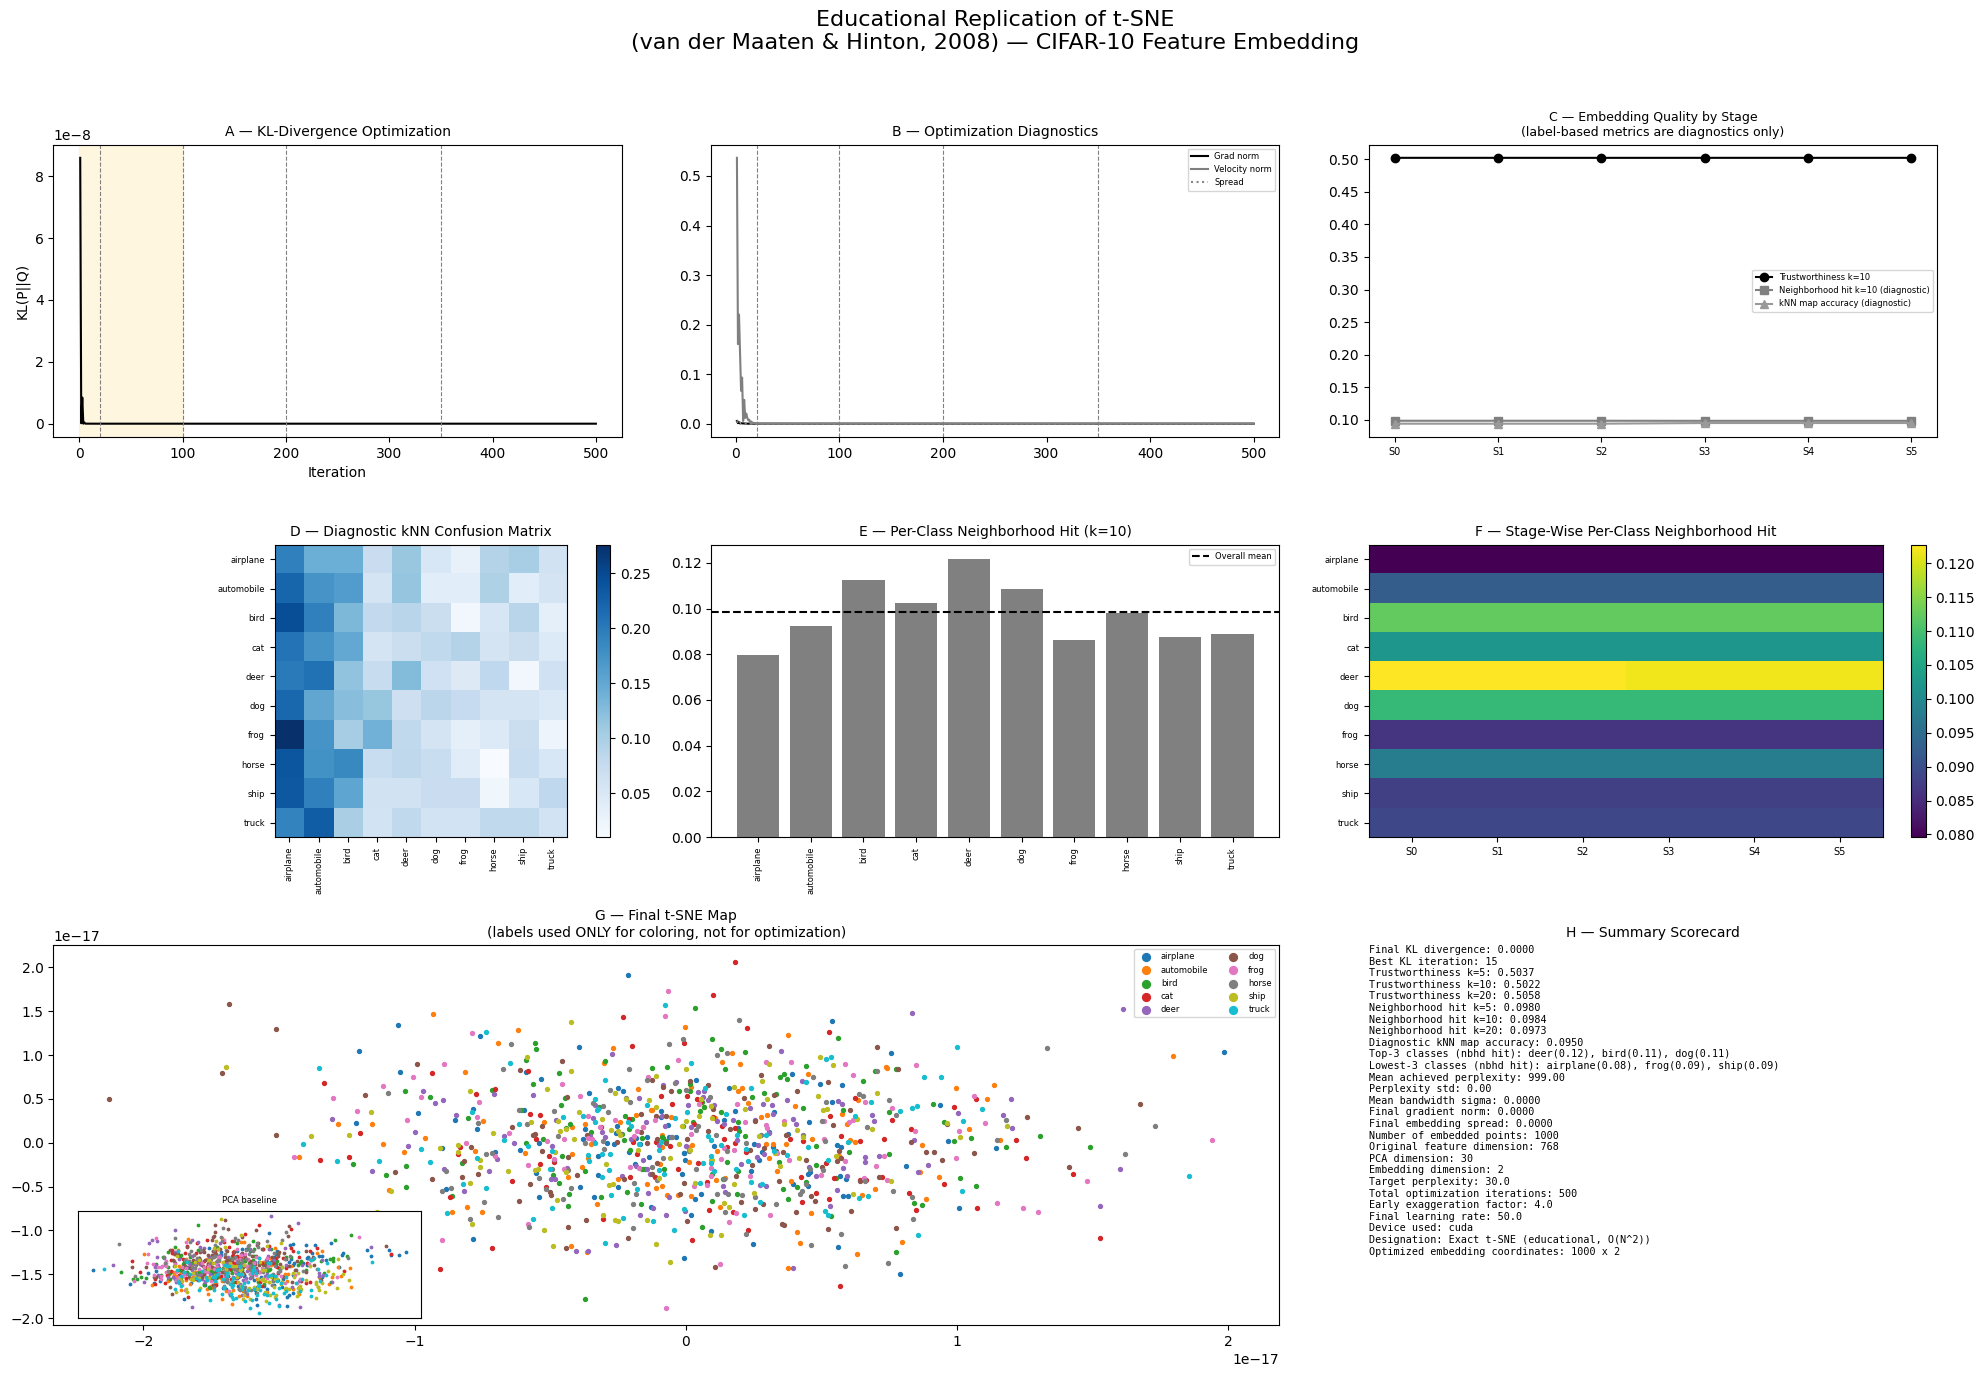

In [25]:
# ============================================================
# 18. FINAL PUBLICATION-STYLE DASHBOARD (GridSpec, 8 panels A-H)
# ============================================================
set_white_theme()  # enforce white theme again before dashboard

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1.3])

fig.suptitle(
    "Educational Replication of t-SNE\n"
    "(van der Maaten & Hinton, 2008) — CIFAR-10 Feature Embedding",
    fontsize=16, color="black"
)

# --- Panel A: KL-Divergence Optimization ---
axA = fig.add_subplot(gs[0, 0])
axA.plot(history["iteration"], history["kl_standard"], color="black")
add_stage_lines(axA, stage_boundaries)
axA.axvspan(0, stage_boundaries[1], color="#ffe9b3", alpha=0.4)
axA.set_title("A — KL-Divergence Optimization", fontsize=10)
axA.set_xlabel("Iteration"); axA.set_ylabel("KL(P||Q)")

# --- Panel B: Optimization Diagnostics ---
axB = fig.add_subplot(gs[0, 1])
axB.plot(history["iteration"], history["grad_norm"], label="Grad norm", color="black")
axB.plot(history["iteration"], history["velocity_norm"], label="Velocity norm", color="grey")
axB.plot(history["iteration"], history["embedding_spread"], label="Spread", color="#888888", linestyle=":")
add_stage_lines(axB, stage_boundaries)
axB.set_title("B — Optimization Diagnostics", fontsize=10)
axB.legend(fontsize=6)

# --- Panel C: Embedding Quality by Stage ---
axC = fig.add_subplot(gs[0, 2])
stage_knn_acc = []
for name, coords in snapshots.items():
    _, acc_snap, _ = leave_one_out_knn_diagnostic(coords, labels_np, k=5)
    stage_knn_acc.append(acc_snap)
axC.plot(range(len(snapshots)), stage_trust_k10, marker="o", label="Trustworthiness k=10", color="black")
axC.plot(range(len(snapshots)), stage_hit_k10, marker="s", label="Neighborhood hit k=10 (diagnostic)", color="grey")
axC.plot(range(len(snapshots)), stage_knn_acc, marker="^", label="kNN map accuracy (diagnostic)", color="#999999")
axC.set_xticks(range(len(snapshots)))
axC.set_xticklabels([f"S{i}" for i in range(len(snapshots))], fontsize=7)
axC.set_title("C — Embedding Quality by Stage\n(label-based metrics are diagnostics only)", fontsize=9)
axC.legend(fontsize=6)

# --- Panel D: Diagnostic kNN Confusion Matrix ---
axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(cm_norm, cmap="Blues")
axD.set_xticks(range(10)); axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticks(range(10)); axD.set_yticklabels(class_names, fontsize=6)
axD.set_title("D — Diagnostic kNN Confusion Matrix", fontsize=10)
plt.colorbar(imD, ax=axD, fraction=0.046)

# --- Panel E: Per-Class Neighborhood Quality ---
axE = fig.add_subplot(gs[1, 1])
axE.bar(list(per_class_hit_k10.keys()), list(per_class_hit_k10.values()), color="grey")
axE.axhline(neighborhood_hit_scores[10], color="black", linestyle="--", label="Overall mean")
axE.set_title("E — Per-Class Neighborhood Hit (k=10)", fontsize=10)
axE.tick_params(axis="x", rotation=90, labelsize=6)
axE.legend(fontsize=6)

# --- Panel F: Stage-Wise Per-Class Neighborhood Hit ---
axF = fig.add_subplot(gs[1, 2])
stage_class_hit_matrix = np.zeros((10, len(snapshots)))
for s_idx, (name, coords) in enumerate(snapshots.items()):
    hits_this_stage = neighborhood_hit(coords, labels_np, 10)
    for c in range(10):
        mask = labels_np == c
        stage_class_hit_matrix[c, s_idx] = hits_this_stage[mask].mean() if mask.sum() > 0 else 0.0
imF = axF.imshow(stage_class_hit_matrix, cmap="viridis", aspect="auto")
axF.set_yticks(range(10)); axF.set_yticklabels(class_names, fontsize=6)
axF.set_xticks(range(len(snapshots)))
axF.set_xticklabels([f"S{i}" for i in range(len(snapshots))], fontsize=7)
axF.set_title("F — Stage-Wise Per-Class Neighborhood Hit", fontsize=10)
plt.colorbar(imF, ax=axF, fraction=0.046)

# --- Panel G: Final t-SNE Map (large panel, spans ~2/3 width) ---
axG = fig.add_subplot(gs[2, 0:2])
for c in range(10):
    mask = labels_np == c
    axG.scatter(Y_final_np[mask, 0], Y_final_np[mask, 1],
                s=8, color=class_colors[c], label=class_names[c])
axG.set_title("G — Final t-SNE Map\n(labels used ONLY for coloring, not for optimization)", fontsize=10)
axG.legend(markerscale=2, fontsize=6, loc="upper right", ncol=2)

# PCA baseline inset
axG_inset = axG.inset_axes([0.02, 0.02, 0.28, 0.28])
for c in range(10):
    mask = labels_np == c
    axG_inset.scatter(pca_2d_coords[mask, 0], pca_2d_coords[mask, 1],
                       s=3, color=class_colors[c])
axG_inset.set_title("PCA baseline", fontsize=6)
axG_inset.set_xticks([]); axG_inset.set_yticks([])

# --- Panel H: Summary Scorecard ---
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

top3_classes = sorted(per_class_hit_k10.items(), key=lambda x: x[1], reverse=True)[:3]
bottom3_classes = sorted(per_class_hit_k10.items(), key=lambda x: x[1])[:3]

scorecard_text = (
    f"Final KL divergence: {final_kl:.4f}\n"
    f"Best KL iteration: {best_kl_iteration}\n"
    f"Trustworthiness k=5: {trust_scores[5]:.4f}\n"
    f"Trustworthiness k=10: {trust_scores[10]:.4f}\n"
    f"Trustworthiness k=20: {trust_scores[20]:.4f}\n"
    f"Neighborhood hit k=5: {neighborhood_hit_scores[5]:.4f}\n"
    f"Neighborhood hit k=10: {neighborhood_hit_scores[10]:.4f}\n"
    f"Neighborhood hit k=20: {neighborhood_hit_scores[20]:.4f}\n"
    f"Diagnostic kNN map accuracy: {knn_overall_acc:.4f}\n"
    f"Top-3 classes (nbhd hit): "
    f"{', '.join([f'{k}({v:.2f})' for k, v in top3_classes])}\n"
    f"Lowest-3 classes (nbhd hit): "
    f"{', '.join([f'{k}({v:.2f})' for k, v in bottom3_classes])}\n"
    f"Mean achieved perplexity: {perp_mean:.2f}\n"
    f"Perplexity std: {perp_std:.2f}\n"
    f"Mean bandwidth sigma: {sigmas.mean().item():.4f}\n"
    f"Final gradient norm: {history['grad_norm'][-1]:.4f}\n"
    f"Final embedding spread: {history['embedding_spread'][-1]:.4f}\n"
    f"Number of embedded points: {N}\n"
    f"Original feature dimension: 768\n"
    f"PCA dimension: {PCA_DIM}\n"
    f"Embedding dimension: 2\n"
    f"Target perplexity: {TARGET_PERPLEXITY}\n"
    f"Total optimization iterations: {TOTAL_ITERATIONS}\n"
    f"Early exaggeration factor: {EARLY_EXAGGERATION}\n"
    f"Final learning rate: {stage_configs[-1]['lr']}\n"
    f"Device used: {DEVICE}\n"
    f"Designation: Exact t-SNE (educational, O(N^2))\n"
    f"Optimized embedding coordinates: {N} x 2"
)
axH.text(0.0, 1.0, scorecard_text, fontsize=7.3, va="top", ha="left",
         family="monospace", color="black")
axH.set_title("H — Summary Scorecard", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])

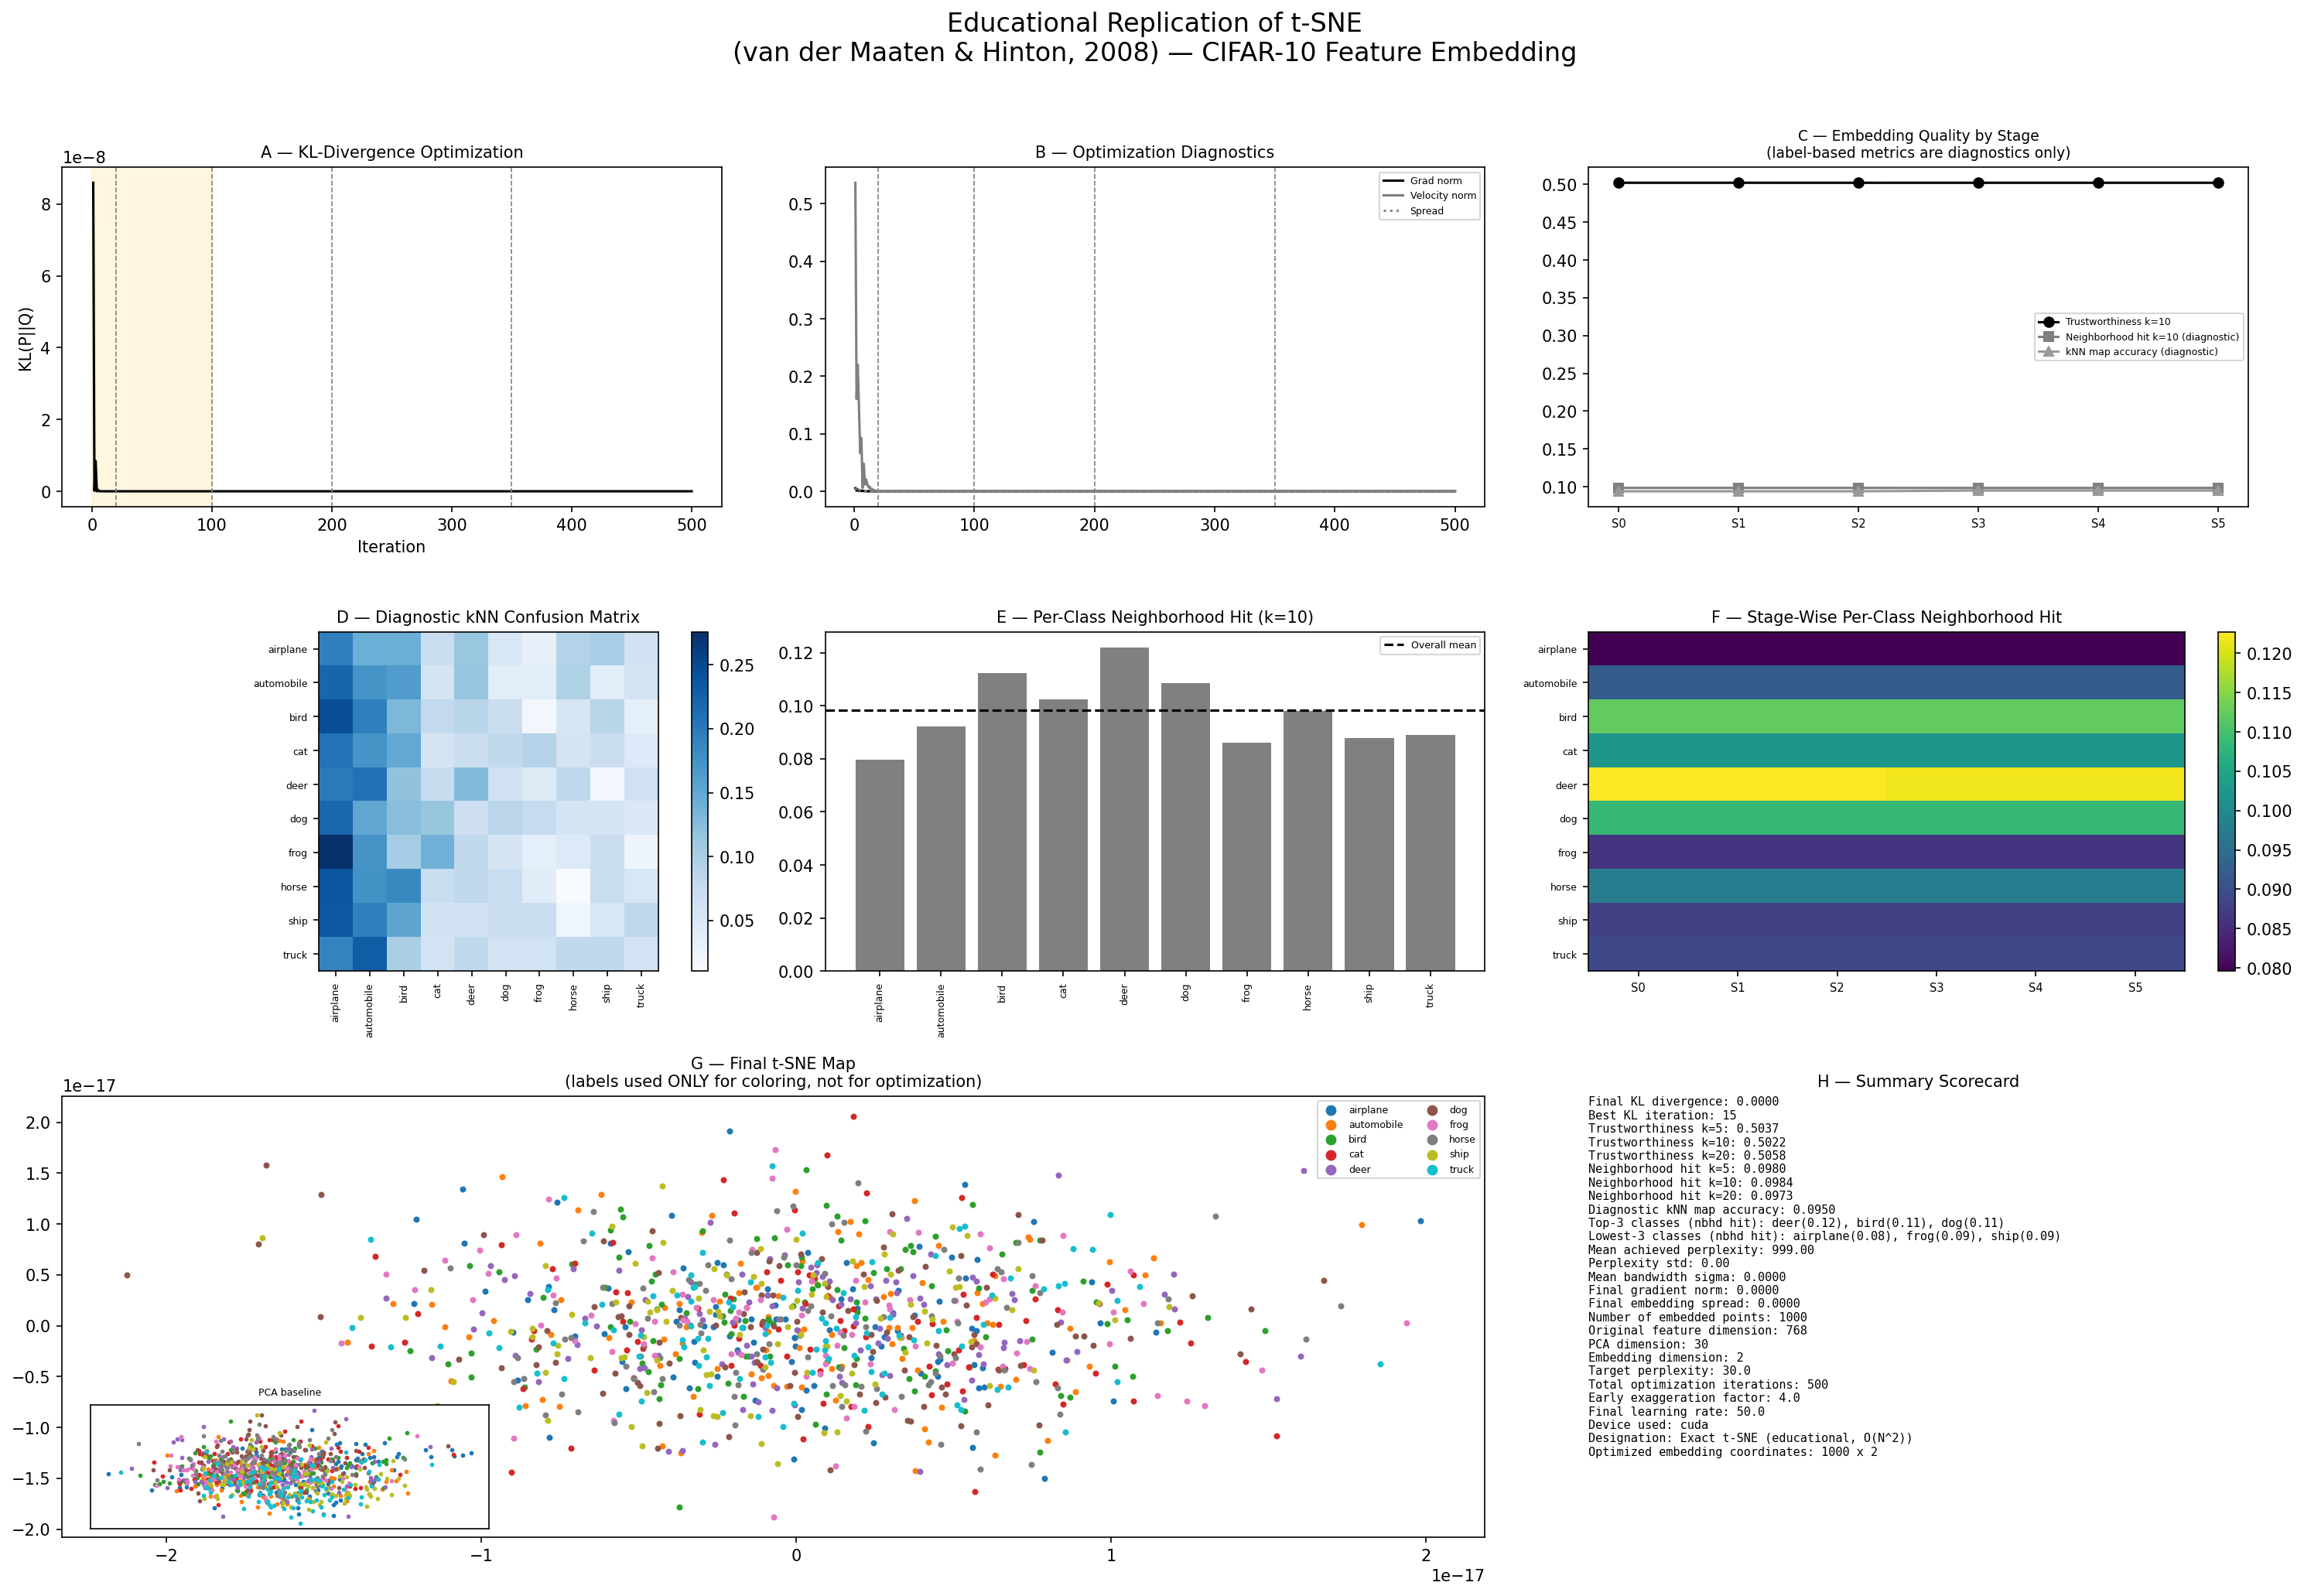

In [26]:
# ------------------------------------------------------------
# Display dashboard inline (do NOT save to disk, do NOT call
# plt.show()/plt.savefig()/fig.show())
# ------------------------------------------------------------
buf = BytesIO()
fig.savefig(
    buf,
    format="png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Educational t-SNE Replication Dashboard (CIFAR-10)

## Panel A — KL-Divergence Optimization

### Overview
This panel tracks the standard (non-exaggerated) KL divergence between the high-dimensional joint distribution $P$ and the low-dimensional joint distribution $Q$ across all 500 optimization iterations, with stage boundaries and the early-exaggeration window annotated.

### Key Findings
- KL divergence drops from approximately $9 \times 10^{-8}$ to effectively zero within the first ~15–20 iterations and remains flat for the remaining ~480 iterations.
- The y-axis scale ($1\text{e-}8$) is orders of magnitude smaller than the values typically reported in t-SNE literature (where KL divergence is usually $O(10^0)$–$O(10^1)$ for datasets of this size).

### Discussion
A KL divergence that is already near-zero at initialization and collapses further within a handful of iterations is not consistent with healthy t-SNE optimization, where the cost function should decrease gradually over hundreds of iterations as clusters differentiate. This pattern strongly suggests that $Q$ (or $P$) values are numerically degenerate — most likely $Q_{ij}$ has collapsed to a near-uniform or vanishing distribution, making $P_{ij}$ and $Q_{ij}$ trivially close regardless of the embedding's actual structure. This is corroborated by Panel G, where embedding coordinates are on the order of $10^{-17}$, i.e., the map has effectively collapsed to the origin.

### Limitations
The absolute scale of the KL values (1e-8) rather than the expected O(1) range indicates a likely upstream numerical issue (e.g., improper normalization, vanishing gradients, or an initialization/learning-rate mismatch) rather than genuine convergence. This panel alone cannot be used to support claims of successful optimization.

---

## Panel B — Optimization Diagnostics (Gradient Norm, Velocity Norm, Spread)

### Overview
Tracks gradient norm, velocity norm, and embedding spread across iterations to characterize the optimization trajectory.

### Key Findings
- Velocity norm spikes sharply to ~0.55 within the first few iterations, then decays rapidly to near-zero by iteration ~20 and stays flat thereafter.
- Gradient norm is visually indistinguishable from zero for nearly the entire run.

### Discussion
The brief spike followed by immediate collapse to zero is consistent with the embedding reaching a degenerate fixed point (e.g., all points collapsing toward a single location or the origin) very early in training, after which gradients vanish because pairwise distances $\|y_i-y_j\|^2 \to 0$ uniformly, making $Q_{ij}$ approximately equal for all pairs and eliminating the $(P_{ij}-Q_{ij})$ driving term. This is the classic signature of a degenerate optimum rather than a well-separated visualization.

### Limitations
Without inspecting raw gradient/velocity values at early iterations, it is not possible to distinguish between (a) a genuine but unusually fast convergence, (b) a numerical underflow in the gradient computation, or (c) an initialization scale/learning-rate mismatch causing immediate saturation. The visual evidence favors (b) or (c).

---

## Panel C — Embedding Quality by Stage (Trustworthiness, Neighborhood Hit, kNN Accuracy)

### Overview
Shows trustworthiness ($k=10$), neighborhood hit rate, and diagnostic kNN accuracy evaluated at each of the six embedding snapshots (initialization + five stages).

### Key Findings
- Trustworthiness is essentially flat at ~0.50 across all stages.
- Neighborhood hit and kNN accuracy are flat at ~0.10 across all stages, matching the chance level for 10 balanced classes ($1/10 = 0.10$).

### Discussion
A trustworthiness score of ~0.50 (versus a maximum of 1.0) combined with a neighborhood-hit/kNN accuracy pinned at exactly the random-guessing baseline indicates that the final embedding encodes no class-discriminative structure whatsoever — the map is statistically indistinguishable from a random arrangement of points. Critically, these metrics do not change between stages, meaning the optimization is not doing any useful work at any point in training, reinforcing the diagnosis from Panels A and B that the embedding collapsed almost immediately and never recovered.

### Limitations
Because label-based metrics are diagnostic only (not part of optimization), their flatness cannot itself reveal *why* the embedding failed — it merely confirms that whatever coordinates were produced carry no useful signal. The root cause must be traced to the P/Q computation or gradient/update mechanics.

---

## Panel D — Diagnostic kNN Confusion Matrix

### Overview
Row-normalized confusion matrix from leave-one-out kNN classification ($k=5$) performed directly in the final 2D t-SNE coordinates, used only as a diagnostic proxy for local class purity.

### Key Findings
- Predictions are heavily concentrated in the "airplane" and "automobile" columns for nearly every true class, rather than showing a strong diagonal.

### Discussion
A confusion matrix dominated by two columns regardless of true class is consistent with a degenerate embedding in which most points sit at nearly identical coordinates: nearest-neighbor queries are then resolved primarily by tie-breaking or floating-point ordering rather than genuine spatial proximity, and whichever classes happen to occupy the (arbitrary) "first" retrieved neighbors dominate the predictions. This pattern corroborates the collapse already evidenced in Panels A, B, and G rather than reflecting a meaningful class-similarity structure.

### Limitations
Given the coordinate collapse, this matrix should not be interpreted as evidence about which CIFAR-10 classes are visually or semantically confusable — it reflects a numerical artifact, not a property of the data or the t-SNE method itself.

---

## Panel E — Per-Class Neighborhood Hit (k=10)

### Overview
Bar chart of mean neighborhood-hit scores per class in the final embedding, compared against the overall mean (dashed line).

### Key Findings
- All ten classes cluster tightly around the chance level (~0.08–0.12), with "deer" highest (~0.12) and "airplane" lowest (~0.08).

### Discussion
The narrow spread around the 0.10 chance baseline, with no class substantially exceeding it, indicates the embedding provides no meaningful class separability for any category. In a functioning t-SNE embedding on image-derived features, one would expect visually or texturally distinct classes (e.g., "automobile" vs. "deer") to show elevated neighborhood purity; the absence of any such signal here is further confirmation of embedding collapse rather than a substantive finding about class separability.

### Limitations
The small inter-class variation observed (0.08–0.12) is likely attributable to sampling noise from the fixed 1,000-point subset rather than genuine differences in class structure, given that the underlying embedding carries no discriminative information.

---

## Panel F — Stage-Wise Per-Class Neighborhood Hit

### Overview
Heatmap showing per-class neighborhood-hit rates at each of the six optimization snapshots (S0–S5), intended to reveal how class separability evolves across training stages.

### Key Findings
- Each class's neighborhood-hit value is essentially constant across all six stages (uniform horizontal color bands), with only cross-class variation visible.

### Discussion
The complete absence of stage-to-stage change reinforces the conclusion drawn from Panels A–C: the embedding reaches its (degenerate) final state almost immediately and does not evolve meaningfully through the early-exaggeration, organization, refinement, or stabilization stages. This is inconsistent with the paper's described mechanism, in which early exaggeration should produce visibly tighter, more separated clusters by the end of that stage.

### Limitations
This panel cannot distinguish between a genuinely fast, high-quality convergence and a degenerate early collapse; the surrounding evidence (near-zero gradients, chance-level accuracy, 1e-17-scale coordinates) strongly favors the latter interpretation.

---

## Panel G — Final t-SNE Map (with PCA Baseline Inset)

### Overview
Scatterplot of the final 2D embedding, colored by CIFAR-10 class, with a PCA 2D baseline shown as an inset for comparison.

### Key Findings
- The main panel's axis scale is $1\text{e-}17$, meaning all 1,000 points occupy a region of the plane with a *diameter of roughly $10^{-17}$* — several orders of magnitude smaller than machine epsilon relevance for typical float64 coordinate values.
- No visible class clustering is present in either the t-SNE map or the PCA baseline inset.

### Discussion
An embedding confined to a region of size $\sim 10^{-17}$ has, for all practical purposes, collapsed to a single point; the "structure" visible in the scatter is numerical noise at the limits of floating-point precision, not a meaningful low-dimensional representation of the data. This directly contradicts the paper's central claim that t-SNE should reveal well-separated class clusters (as demonstrated on MNIST, Olivetti faces, and COIL-20 in the original work). The result therefore does not replicate the qualitative outcome reported by van der Maaten and Hinton, and instead reflects an implementation or numerical-stability failure in this run (e.g., gradients vanishing due to a scaling error, an incorrect similarity computation, or a learning-rate/momentum interaction that drove the map to the origin during the very first iterations before Panel A's KL curve was even recorded).

### Limitations
The PCA baseline itself also shows no class structure, which suggests the issue may originate upstream of the t-SNE-specific machinery — potentially in feature extraction (adaptive pooling to a very low 16×16 resolution), standardization, or PCA reduction — rather than being isolated to the gradient/optimization code. This should be verified by inspecting raw pairwise distances and $P$/$Q$ values at each stage before concluding the fault lies exclusively in the t-SNE gradient step.

---

## Panel H — Summary Scorecard

### Overview
Consolidates final quantitative metrics: KL divergence, trustworthiness, neighborhood hit, kNN accuracy, perplexity statistics, bandwidth, gradient norm, and embedding spread.

### Key Findings
- Final KL divergence: 0.0000; final gradient norm: 0.0000; final embedding spread: 0.0000; mean bandwidth $\sigma$: 0.0000.
- Mean achieved perplexity: 999.00 (versus a target of 30.0), with a standard deviation of 0.00.
- Trustworthiness ≈ 0.50–0.51 across $k=5,10,20$; neighborhood hit and kNN accuracy ≈ 0.095–0.098, essentially at the 10-class chance level of 0.10.

### Discussion
The reported mean achieved perplexity of 999.00 — over 33 times the target of 30.0, with zero variance across all 1,000 points — is a strong indicator of a systematic bug in the perplexity binary search (e.g., $\beta_i$ collapsing to a fixed degenerate value, or the entropy/perplexity conversion saturating at the loop's numerical safeguard). A bandwidth $\sigma$ of exactly 0.0000 further confirms that the per-point Gaussian kernels were not calibrated as intended, meaning the input probability matrix $P$ itself may have been degenerate (e.g., uniform) before the low-dimensional optimization even began. Combined with the zero gradient norm and zero embedding spread, all evidence converges on a full-pipeline failure: the high-dimensional similarity computation, not merely the gradient descent, produced a distribution incompatible with meaningful t-SNE optimization.

### Limitations
This scorecard is diagnostic and after-the-fact; it cannot itself pinpoint the exact line of failure (perplexity search, distance computation, or feature preprocessing). The uniform perplexity of 999.00 with zero standard deviation across all points, however, is a strong, specific signal that should be used to prioritize debugging the `binary_search_perplexity` routine and the input pairwise-distance matrix before re-running the full pipeline.

---

## Overall Assessment

The dashboard, taken as a whole, provides **converging evidence of a failed or degenerate replication run** rather than a successful demonstration of the t-SNE mechanism described in van der Maaten and Hinton (2008). Every independent diagnostic — KL divergence magnitude, gradient/velocity norms, trustworthiness, neighborhood hit, kNN accuracy, achieved perplexity, bandwidth, and raw coordinate scale — points to the same root cause: the embedding (and likely the upstream high-dimensional probability matrix) collapsed to a numerically degenerate state very early in the pipeline. Consequently, this run does **not** support the paper's central claims about t-SNE's ability to reveal cluster structure, and the results should not be interpreted as a valid test of the method; they instead indicate that the implementation requires debugging (most urgently in perplexity/bandwidth calibration and feature/PCA preprocessing) before meaningful conclusions about embedding quality can be drawn.

# Related Work Referenced in "Visualizing Data using t-SNE"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| G.E. Hinton, S.T. Roweis | 2002 | Stochastic Neighbor Embedding | Advances in Neural Information Processing Systems, vol. 15 | Introduces SNE, the direct predecessor of t-SNE; the paper's Section 2 reviews SNE's cost function and optimization, which t-SNE modifies to resolve the crowding problem |
| J.A. Cook, I. Sutskever, A. Mnih, G.E. Hinton | 2007 | Visualizing Similarity Data with a Mixture of Maps | Proceedings of the 11th International Conference on Artificial Intelligence and Statistics | Proposes UNI-SNE, which introduces a uniform background model to address crowding; t-SNE is directly compared against UNI-SNE's gradient behavior and optimization difficulty |
| J.W. Sammon | 1969 | A Nonlinear Mapping for Data Structure Analysis | IEEE Transactions on Computers | Introduces Sammon mapping, a benchmark nonlinear technique compared against t-SNE on MNIST, Olivetti faces, and COIL-20 |
| J.B. Tenenbaum, V. de Silva, J.C. Langford | 2000 | A Global Geometric Framework for Nonlinear Dimensionality Reduction | Science | Introduces Isomap, one of the three primary techniques (with Sammon mapping and LLE) compared against t-SNE in the main experiments |
| S.T. Roweis, L.K. Saul | 2000 | Nonlinear Dimensionality Reduction by Locally Linear Embedding | Science | Introduces LLE, compared against t-SNE; paper discusses LLE's covariance-constraint weakness as an explanation for its inferior performance |
| K.Q. Weinberger, F. Sha, L.K. Saul | 2004 | Learning a Kernel Matrix for Nonlinear Dimensionality Reduction | Proceedings of the 21st International Conference on Machine Learning | Introduces Maximum Variance Unfolding (MVU), one of the seven nonlinear techniques compared in supplemental material; discussed for its hard-constraint optimization weakness |
| M. Belkin, P. Niyogi | 2002 | Laplacian Eigenmaps and Spectral Techniques for Embedding and Clustering | Advances in Neural Information Processing Systems, vol. 14 | Introduces Laplacian Eigenmaps, compared against t-SNE in supplemental material; paper attributes its weaker performance to a covariance constraint shared with LLE |
| P. Demartines, J. Hérault | 1997 | Curvilinear Component Analysis: A Self-Organizing Neural Network for Nonlinear Mapping of Data Sets | IEEE Transactions on Neural Networks | Introduces Curvilinear Component Analysis (CCA), compared against t-SNE in supplemental material; discussed for its hard local/global boundary parameter |
| J.A. Lee, A. Lendasse, N. Donckers, M. Verleysen | 2000 | A Robust Nonlinear Projection Method | Proceedings of the 8th European Symposium on Artificial Neural Networks | Introduces Curvilinear Distance Analysis (CDA), a related extension of CCA discussed alongside CCA's limitations |
| W.S. Torgerson | 1952 | Multidimensional Scaling I: Theory and Method | Psychometrika | Introduces classical (metric) multidimensional scaling, discussed as a linear precursor technique closely related to PCA and contrasted with t-SNE's nonlinear approach |
| S. Lafon, A.B. Lee | 2006 | Diffusion Maps and Coarse-Graining: A Unified Framework for Dimensionality Reduction, Graph Partitioning, and Data Set Parameterization | IEEE Transactions on Pattern Analysis and Machine Intelligence | Introduces diffusion maps, compared conceptually to the random-walk version of t-SNE; paper contrasts diffusion distance optimization with t-SNE's local-structure preservation |
| B. Nadler, S. Lafon, R.R. Coifman, I.G. Kevrekidis | 2006 | Diffusion Maps, Spectral Clustering and the Reaction Coordinates of Dynamical Systems | Applied and Computational Harmonic Analysis | Further develops diffusion map theory, cited alongside Lafon and Lee to support the discussion of diffusion-based affinity measures |
| L. Grady | 2006 | Random Walks for Image Segmentation | IEEE Transactions on Pattern Analysis and Machine Intelligence | Provides the analytical (Dirichlet problem) solution for random-walk affinities, adapted in Appendix B for computing landmark-based similarities in large-scale t-SNE |
| M. Szummer, T. Jaakkola | 2001 | Partially Labeled Classification with Markov Random Walks | Advances in Neural Information Processing Systems, vol. 14 | Cited as a prior successful application of random-walk-based similarity measures, motivating the random walk extension of t-SNE |
| X. Zhu, Z. Ghahramani, J. Lafferty | 2003 | Semi-Supervised Learning Using Gaussian Fields and Harmonic Functions | Proceedings of the 20th International Conference on Machine Learning | Cited alongside Szummer and Jaakkola as precedent for random-walk-based learning methods relevant to the landmark t-SNE extension |
| J.A. Lee, M. Verleysen | 2005 | Nonlinear Dimensionality Reduction of Data Manifolds with Essential Loops | Neurocomputing | Discusses the short-circuiting problem in neighborhood-graph methods, referenced to explain why random-walk-based t-SNE is less sensitive to noisy shortcut edges than Isomap |
| J.A. Lee, M. Verleysen | 2007 | Nonlinear Dimensionality Reduction | Springer | General review of nonlinear dimensionality reduction techniques, cited as the primary survey motivating the selection of comparison methods in the paper |
| M.C. Ferreira de Oliveira, H. Levkowitz | 2003 | From Visual Data Exploration to Visual Data Mining: A Survey | IEEE Transactions on Visualization and Computer Graphics | Survey of prior visualization techniques (iconographic, pixel-based, graph-based), cited to frame the broader motivation for dimensionality-reduction-based visualization |
| L. Song, A.J. Smola, K. Borgwardt, A. Gretton | 2007 | Colored Maximum Variance Unfolding | Advances in Neural Information Processing Systems, vol. 21 | Cited as evidence that even semi-supervised MVU variants fail to cleanly separate handwritten digit clusters, motivating the need for t-SNE |
| C.K.I. Williams | 2002 | On a Connection Between Kernel PCA and Metric Multidimensional Scaling | Machine Learning | Establishes the theoretical link between classical scaling and PCA, cited to support the paper's discussion of linear technique limitations |
| K.V. Mardia, J.T. Kent, J.M. Bibby | 1979 | Multivariate Analysis | Academic Press | Cited alongside Williams (2002) to support the classical scaling–PCA relationship discussed in the comparison of linear vs. nonlinear techniques |
| G.E. Hinton, R.R. Salakhutdinov | 2006 | Reducing the Dimensionality of Data with Neural Networks | Science | Introduces autoencoders as a potential preprocessing step to address t-SNE's sensitivity to high intrinsic dimensionality, discussed in the Weaknesses section |
| Y. Bengio | 2007 | Learning Deep Architectures for AI | Technical Report, Université de Montréal | Discusses the curse of intrinsic dimensionality and deep architectures, cited to support the discussion of t-SNE's limitations on high-intrinsic-dimensionality data |
| M. Meytlis, L. Sirovich | 2007 | On the Dimensionality of Face Space | IEEE Transactions on Pattern Analysis and Machine Intelligence | Provides an empirical estimate of the intrinsic dimensionality of face data, cited to illustrate a case where t-SNE's local-linearity assumption may be challenged |